# MINFin in Python

This notebook implements *MinFin*, an analytical model developed to identify energy sector financing gaps for climate transitions in low- and middle-income countries (LMICs). MinFin quantifies investment needs, estimates financing costs, and evaluates anticipated sectoral cashflows to highlight financial shortfalls and explore feasible strategies to bridge them. The model’s primary goal is to facilitate better collaboration between energy and finance ministries, ensuring that energy planning aligns with national financial capacities and macroeconomic considerations. This python version is based on the original Excel version of MinFin, which can be found [here](https://zenodo.org/records/14844158).

## Reading the input data

- We can read the input data from the Excel file using the `pandas` library. The excel sheet we use is the Excel version of MinFin.
- A sample data set is provided in the `data` folder.

In [1]:
# Commented out the below line for installation of pandas if it is already installed
!python3 -m pip install pandas

import pandas as pd

# Define file path
# file_path = "C:\\Users\\Zixuan\\Downloads\\MinFin V1.0.0kc.xlsm"
file_path = "data/MinFin V1.0.0kc.xlsm"
# Load the Excel file and check available sheet names
xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names
# Display sheet names
sheet_names


You should consider upgrading via the 'C:\Users\Zixuan\.pyenv\pyenv-win\versions\3.11.0b4\python3.exe -m pip install --upgrade pip' command.
C:\Users\Zixuan\AppData\Local\Temp\ipykernel_53364\2335663780.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


['Definitions',
 'Visualisation Dashboard',
 'Financial Instruments',
 'High Level Dashboard',
 'Financing Baseline',
 'Funding Baseline',
 'Investment Needs',
 'OSeMOSYS (Input)',
 'FFRM (Input)']

In [2]:
import sys
sys.modules.pop("MinFin", None)  # clean the cache of MinFin module, in case it is changed between runs.
from MinFin import load_excel_data
# MinFin is a Python module designed specifically for this MINFin model
# We import functions from it   
df_param_constraints, df_financing_baseline, df_funding_baseline, df_scenarios, df_currencies, df_technologies =  load_excel_data(file_path)

df_technologies.head(5) # show the first 5 rows of the technologies sheet

ValueError: Length mismatch: Expected axis has 0 elements, new values have 2 elements

In [ ]:
class BaseDefinition:
    def __init__(self, name: str, description: str):
        self.name = name
        self.description = description
    
    def __repr__(self):
        return f"{self.__class__.__name__}(name='{self.name}', description='{self.description}')"

class ParameterConstraint(BaseDefinition):
    pass

class FinancingBaseline(BaseDefinition):
    pass

class FundingBaseline(BaseDefinition):
    pass

class Scenario(BaseDefinition):
    pass

class Currency:
    def __init__(self, code: str, currency: str):
        self.code = code
        self.currency = currency
    
    def __repr__(self):
        return f"Currency(code='{self.code}', currency='{self.currency}')"

class Technology:
    def __init__(self, name: str, description: str, classification: str):
        self.name = name
        self.description = description
        self.classification = classification
    
    def __repr__(self):
        return f"Technology(name='{self.name}', description='{self.description}', classification='{self.classification}')"

# Creating a list of objects from extracted data
def load_definitions_from_dataframe(df, cls):
    return [cls(row["Name"], row["Description"]) for _, row in df.iterrows()]

def load_currencies_from_dataframe(df):
    return [Currency(row["Code"], row["Currency"]) for _, row in df.iterrows()]

def load_technologies_from_dataframe(df):
    return [Technology(row["Name"], row["Description"], row["Classification"]) for _, row in df.iterrows()]

# Example usage:
constraints = load_definitions_from_dataframe(df_param_constraints, ParameterConstraint)
baselines = load_definitions_from_dataframe(df_financing_baseline, FinancingBaseline)
fundings = load_definitions_from_dataframe(df_funding_baseline, FundingBaseline)
scenarios = load_definitions_from_dataframe(df_scenarios, Scenario)
currencies = load_currencies_from_dataframe(df_currencies)
technologies = load_technologies_from_dataframe(df_technologies)

## FFRM Sheet

We load the FFRM sheet here, for the stranded cost of oil, gas, and coal.

In [ ]:
pd.set_option('future.no_silent_downcasting', True)# This is to avoid the warning of downcasting the data types. No need to worry about it.

# Load the entire "OSeMOSYS (Input)" sheet once to avoid multiple reads
df_osemosys_full = pd.read_excel(file_path, sheet_name="OSeMOSYS (Input)")#, engine="openpyxl")
df_ffrm_full = pd.read_excel(file_path, sheet_name="FFRM (Input)")

In [ ]:
def process_ffrm_input(df_ffrm_full):
    """
    Load FFRM Input data for Oil, Gas, and Coal into a structured DataFrame.
    
    Parameters:
    df_ffrm_full (DataFrame): The full FFRM (Input) sheet from the Excel file.

    Returns:
    DataFrame: A merged DataFrame containing all energy types with multi-level column names.
    """
    starting_cols = {'Oil': 1, 'Gas': 4, 'Coal': 7}  # Define starting columns
    starting_row = 5
    dfs = []  # List to store data from each energy type

    for energy_type, starting_col in starting_cols.items():
        # Extract relevant section
        df = df_ffrm_full.iloc[starting_row:starting_row+48, starting_col:starting_col+2].copy()  # +3 to ensure all columns
        
        # Extract the column headers
        scenarios = df_ffrm_full.iloc[starting_row-1, starting_col:starting_col+2].dropna().tolist()
        
        # Check if we extracted the correct number of columns
        if len(scenarios) != df.shape[1]:
            print(f"Warning: Column count mismatch for {energy_type}. Expected {df.shape[1]}, got {len(scenarios)}.")
            print(f"Scenarios found: {scenarios}")

        # Define column names with MultiIndex format (EnergyType, Scenario)
        df.columns = pd.MultiIndex.from_product([[energy_type], scenarios[:df.shape[1]]])  # Ensure header length matches

        # Insert Year column
        df.insert(0, ("General", "Year"), df_ffrm_full.iloc[starting_row:starting_row+48, 0].values)

        # Fill missing values with 0
        df.iloc[:, 1:] = df.iloc[:, 1:].fillna(0)
        df.reset_index(drop=True, inplace=True)
        # Compute stranded cost and add it as a new column
        if len(scenarios) >= 2:
            df[(energy_type, "Stranded Cost")] = df[(energy_type, scenarios[1])] - df[(energy_type, scenarios[0])]

        # Append to list
        dfs.append(df)

    # Merge all energy types into a single DataFrame
    df_final = pd.concat(dfs, axis=1)

    # Remove duplicate Year columns (keep only one)
    df_final = df_final.loc[:, ~df_final.columns.duplicated()]

    return df_final

# We process the raw FFRM sheet here, plus compute the stranded cost of oil, gas, and coal.
df_ffrm = process_ffrm_input(df_ffrm_full)

df_ffrm.head(5)


General     Oil                             Gas                          \
     Year NetZero LeastCost Stranded Cost NetZero LeastCost Stranded Cost   
0    2023       0         0             0       0         0             0   
1    2024       0         0             0       0         0             0   
2    2025       0         0             0       0         0             0   
3    2026       0         0             0       0         0             0   
4    2027       0         0             0       0         0             0   

     Coal                          
  NetZero LeastCost Stranded Cost  
0      34        56            22  
1      35        58            23  
2      36        60            24  
3      37        62            25  
4      38        64            26

## Here we extract the currency/exchange rate information: 
- We currenly generate random rates, can extract from the internet or set to be user-defined.
- It is not taking effect in the further processing of the data, as we use USD as default

In [ ]:
import numpy as np
# Define the years from 2015 to 2079
years = np.arange(2000, 2080)

# Define some example currencies
currencies = ["EUR", "GBP", "JPY", "CNY", "INR", "AUD", "CAD"]

# Generate synthetic exchange rates with a simulated yearly change
np.random.seed(42)  # For reproducibility
base_rates = {
    'USD': 1#, "EUR": 1.1, "GBP": 1.3, "JPY": 110, "CNY": 6.5, "INR": 74, "AUD": 1.4, "CAD": 1.25
}
base_rates["KES"] = 1

# Simulate yearly fluctuations for KES (small changes)
fluctuations = np.cumsum(np.random.normal(0, 0.01, len(years)))  # Simulated yearly change
# Create a DataFrame to store the exchange rates
exchange_rates = pd.DataFrame({"Year": years})
exchange_rates["KES"] = base_rates["KES"]# * (1 + fluctuations)
# exchange_rates["USD"] = base_rates["USD"]
# Simulate yearly fluctuations in exchange rates
for currency, base_rate in base_rates.items():
    fluctuations = np.cumsum(np.random.normal(0, 0.01, len(years)))  # Simulated yearly change
    exchange_rates[currency] = base_rate #* (1 + fluctuations)
exchange_rates
melted_exchange_rates = exchange_rates.melt(id_vars=["Year"], var_name="Currency", value_name="Exchange Rate")
melted_exchange_rates.T


,0,1,2,3,4,5,6,7,8,9,...,150,151,152,153,154,155,156,157,158,159
Year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2070,2071,2072,2073,2074,2075,2076,2077,2078,2079
Currency,KES,KES,KES,KES,KES,KES,KES,KES,KES,KES,...,USD,USD,USD,USD,USD,USD,USD,USD,USD,USD
Exchange Rate,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


## Funding Baseline Sheet

Here we read and process the historic funding information from the excel sheet

In [ ]:
# Load the "Funding Baseline" sheet from the Excel file

from MinFin import process_funding_baseline

# Read the full "Funding Baseline" sheet
df_funding_baseline_full = pd.read_excel(file_path, sheet_name="Funding Baseline", engine="openpyxl")
df_final = process_funding_baseline(df_funding_baseline_full,melted_exchange_rates)
df_funding_baseline=process_funding_baseline(df_funding_baseline_full,melted_exchange_rates)
df_funding_baseline.head(2)

c:\Users\Zixuan\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Data Validation extension is not supported and will be removed



,Source,Name,Type,Year,Volume (Million),Currency,Govt Share,Volume (Foreign Currency USD),Exchange Rate,volume_in_usd
0,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2010,212.585322,USD,1,212.585322,1.0,212.585322
1,GoK MoEP Budget,GoK MoEP Budget (Renewables),Budget,2011,212.585322,USD,1,212.585322,1.0,212.585322


- And get the funding envolope from the input

In [ ]:
from MinFin import get_funding_envelope

df_funding_envelope=get_funding_envelope(df_funding_baseline)
df_funding_envelope.head(3)

Type,Budget,Grant,SOE Gen.
Year,,,
2010,212.585322,8.15,136.589319
2011,212.585322,17.5,137.046688
2012,212.585322,0,136.393265


## OSeMOSYS Sheet

Here we import a Python class to extract OSeMOSYS data from the module we develop

In [ ]:
from MinFin import osemosys_extractor
# df_osemosys_full

### Net Zero Scenario
example for reading the NZ data

In [ ]:
net_zero_extrator = osemosys_extractor('net_zero')
net_zero_summary = net_zero_extrator.get_totals(df_osemosys_full)
full_cap_cost_net_zero, df_ffe_net_zero = osemosys_extractor.load_osemosys_input('net_zero',df_osemosys_full)

#Display sample results
net_zero_summary.head(3)
# df_ffe_net_zero.head(3)

,variable_cost,fixed_cost,annual_elec_production,co2_emission,carbon_price,capital_cost,total_cost,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,139.3078,224.812,335.7137,0.4391,67.060662,869.3439,1233.4637,3.674154,1.020598,29.446337
2026,83.7825,237.1475,349.8989,0.1041,68.569526,978.1743,1299.1043,3.712799,1.031333,7.138088
2027,118.2583,239.7243,367.1226,0.1982,70.112341,966.7791,1324.7617,3.608499,1.002361,13.896266


### Least Cost Scenario
example for reading the LC data

In [ ]:
least_cost_extrator = osemosys_extractor('least_cost')
least_cost_summary =  least_cost_extrator.get_totals(df_osemosys_full)
full_cap_cost_least_cost, df_ffe_least_cost = osemosys_extractor.load_osemosys_input('least_cost',df_osemosys_full)
least_cost_summary.head(3)

,variable_cost,fixed_cost,annual_elec_production,co2_emission,carbon_price,capital_cost,total_cost,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,139.3078,224.812,335.7138,0.4391,67.060662,569.3439,933.4637,2.780534,0.772371,29.446337
2026,83.7825,237.1475,349.8989,0.1041,68.569526,978.1743,1299.1043,3.712799,1.031333,7.138088
2027,100.4543,244.5441,367.5427,0.1522,70.112341,1085.6692,1430.6676,3.892521,1.081256,10.671098


- We then calculate the CO2 savings from least cost and net zero scenarios

In [ ]:
co2_savings = pd.DataFrame()
co2_savings['co2_savings'] = least_cost_summary['cost_of_co2']-net_zero_summary['cost_of_co2']
co2_savings.head(3)

,co2_savings
2025,0.0
2026,0.0
2027,-3.225168


- In the following cell, we calculate the total costs for different scenarios

In [ ]:
#2025 -2070 period total
cost_keys = ['capital_cost','variable_cost','fixed_cost']
data = []
for key in cost_keys:
    data.append({
        "Scenarios": key,  # Scenarios: net zero / least cost
        "NetZero": net_zero_summary[key].sum(),# Million USD
        "LeastCost": least_cost_summary[key].sum(),#Million USD
    })
# net_zero_summary['capital_cost']
period_total = pd.DataFrame(data).T
period_total.columns = period_total.iloc[0] 
period_total = period_total[1:]
period_total['total'] = period_total.iloc[0:,:].sum(axis=1)
period_total

Scenarios,capital_cost,variable_cost,fixed_cost,total
NetZero,131149.5675,5254.9279,42852.2537,179256.7491
LeastCost,129624.9373,6543.0711,42995.5927,179163.6011


### Slide window average 
- here we compute the 5 year windown average for various data.

In [ ]:
five_year_intervals = list(range(2025, 2070, 5))  # Generates [2025, 2030, 2035, ..., 2065]
df_5yr_avg = pd.DataFrame({"Year": five_year_intervals})
# Compute 5-year averages for each interval
for key in cost_keys:
    df_5yr_avg[f"nz_{key}"] = net_zero_summary[key].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False) \
                                             .mean().reset_index(drop=True)
    df_5yr_avg[f"lc_{key}"] = least_cost_summary[key].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False) \
                                             .mean().reset_index(drop=True)
    df_5yr_avg[f"delta_{key}"] = df_5yr_avg[f"lc_{key}"] - df_5yr_avg[f"nz_{key}"]
    
df_5yr_avg["emission_saving"] = co2_savings["co2_savings"].groupby(pd.cut(net_zero_summary.index, 
                                                              bins=list(range(2025, 2071, 5)), 
                                                              labels=five_year_intervals,right=False),observed=False).mean().reset_index(drop=True)    
df_5yr_avg.head(3)         
         

,Year,nz_capital_cost,lc_capital_cost,delta_capital_cost,nz_variable_cost,lc_variable_cost,delta_variable_cost,nz_fixed_cost,lc_fixed_cost,delta_fixed_cost,emission_saving
0,2025,1081.1973,1044.97532,-36.22198,109.8241,99.17112,-10.65298,248.98792,251.86846,2.88054,-1.815091
1,2030,1261.28836,1271.49458,10.20622,79.13008,90.10292,10.97284,348.24074,343.6103,-4.63044,3.863266
2,2035,1665.83412,1719.46714,53.63302,75.38272,72.27926,-3.10346,462.64224,464.05672,1.41448,5.999035


## Investment Needs 
- with input we have processed, we now calculate the investment needs

In [ ]:
import pandas as pd
import numpy as np

global since_year 
since_year= 2025
def filter_data(data):
    data["Year"] = pd.to_numeric(data["Year"], errors='coerce')
    data = data[data["Year"]>=since_year]
    return data


def cal_invest_needs(least_cost_summary,net_zero_summary,df_ffe_least_cost,df_ffe_net_zero,df_ffrm):
    """Extracts and constructs the Investment Needs table from OSeMOSYS and FFRM sheets."""
    df_emission_savings = pd.DataFrame()
    df_emission_savings['emission_savings'] = least_cost_summary['co2_emission']-net_zero_summary['co2_emission']
    
    '''
    Savings on Fossil Fuel Expenditure
    '''
    fossil_fuel_savings = pd.DataFrame()
    
    fossil_fuel_savings = filter_data(df_ffe_least_cost)-filter_data(df_ffe_net_zero)
    fossil_fuel_no_earnings = fossil_fuel_savings.drop(columns=["Total", "Year"], errors="ignore").copy()  # Assuming df_funding_develop is the DataFrame

    fossil_fuel_no_earnings.iloc[:, :-1] = fossil_fuel_no_earnings.map(lambda x: max(x, 0))
    fossil_fuel_savings['Year'] = filter_data(df_ffe_least_cost)["Year"].astype(int)
    fossil_fuel_savings["expenditure"] = fossil_fuel_no_earnings.sum(axis=1)
    # for key in ["coal","oil","gas","biomass"]:
    #     fossil_fuel_savings[key] = 
    '''
    Financing Needs for FFR
    '''
    tech_list = ['Oil', 'Gas', 'Coal']

    df_financing_needs_ffr = df_ffrm.copy()
    for tech in tech_list:
        df_financing_needs_ffr.loc[:, (tech,tech)] = pd.DataFrame( df_ffrm[tech]['LeastCost'] - df_ffrm[tech]['NetZero'])
    
    # 用循环后求出 'Oil', 'Gas', 'Coal' 对应列的总和，并放到 ('Total','Total') 列中
    total_cols = [(tech, tech) for tech in tech_list]
    df_financing_needs_ffr.loc[:, ('Total', 'Total')] = df_financing_needs_ffr.loc[:, total_cols].sum(axis=1)

    '''
    Least Cost Financing needs
    '''
    
    # Calculate total financing needs for each technology category
    # Create a mapping of technology names to their categories
    tech_category_map = {tech.name: tech.classification for tech in technologies}

    #### LEAST COST:####
    # Create a new DataFrame to store the sum of costs per category for each year
    df_category_sum_lc = full_cap_cost_least_cost.copy()

    # Replace technology names with their corresponding categories
    df_category_sum_lc = df_category_sum_lc.rename(columns=tech_category_map)

    # Sum across the same category names (grouping columns with the same category)
    df_category_sum_lc = df_category_sum_lc.T.groupby(level=0).sum().T

    df_category_sum_lc  = filter_data(df_category_sum_lc)
    
    #### NET ZERO:####
    df_category_sum_nz = full_cap_cost_net_zero.copy()

    df_category_sum_nz = df_category_sum_nz.rename(columns=tech_category_map)

    df_category_sum_nz = df_category_sum_nz.T.groupby(level=0).sum().T

    df_category_sum_nz  = filter_data(df_category_sum_nz)
    

    return df_category_sum_lc,df_category_sum_nz,df_emission_savings,df_financing_needs_ffr.set_index(("General","Year"),drop=False),fossil_fuel_savings

# Example Usage

df_category_sum_lc,df_category_sum_nz,df_emission_savings,df_financing_needs_ffr,fossil_fuel_savings= cal_invest_needs(least_cost_summary,net_zero_summary,df_ffe_least_cost,df_ffe_net_zero,df_ffrm)

# df_category_sum_lc.index.name = None

'''
The following line are for fitting a bug in MinFin 1.0.0
'''
categories_to_exclude = ['Offshore Wind', 'Onshore Wind']  # Replace with the categories you want to exclude
'''
##################################################################################################################
'''
df_category_sum_lc.set_index("Year",drop=True).drop(columns=categories_to_exclude).sum(axis=1).copy()
df_category_sum_nz.set_index("Year",drop=True).drop(columns=categories_to_exclude).sum(axis=1).copy()
incremental_investment = df_category_sum_nz - df_category_sum_lc
incremental_investment["Year"] = df_category_sum_lc["Year"]
incremental_investment_total = incremental_investment.set_index(df_category_sum_lc['Year']).drop(columns=categories_to_exclude+["Year"]).sum(axis=1)
df_category_sum_lc
# Assuming the data is stored in a pandas DataFrame called df_category_sum_lc
incremental_investment_total.head(3)
# incremental_investment
# df_category_sum_nz

Year
2025.0      300.0
2026.0        0.0
2027.0    32.4531
dtype: object

## Investment Needs Summary by Technology Category
This section categorizes energy technologies into four main groups and calculates the total investment needs for each category:
1. Renewable Energy: Includes Biomass, Geothermal, Solar PV, CSP, Hydropower, Wind, and Nuclear technologies
2. Fossil Fuel: Includes Coal, Gas, and Oil technologies
3. Power Grid: Includes Transmission and Distribution infrastructure
4. Wind: Onshore and Offshore(`issues in MinFin 1.0 excel`)
5. Other: Any remaining technologies not categorized above
   
The function get_investment_needs_summary() performs this categorization by:
Taking investment data by individual technology as input
- Grouping technologies into broader categories
- Calculating the sum of investments for each category
- Providing yearly investment totals across all categories
  
We apply this function to our Least Cost scenario investment data first to understand how investment flows are distributed across these major technology categories over time.

In [ ]:
# Define category mappings
def get_investment_needs_summary(df_category_sum):
    tech_categories = {
        "Renewable": ["Biomass", "Geothermal", "Solar PV", "CSP", "Hydropower", "Wind", "Nuclear"],
        "Fossil Fuel": ["Coal", "Gas", "Oil"],
        "Power Grid": ["Transmission", "Distribution"],
        "Other": ["Other","other"]
    }

    # Ensure technology names in DataFrame match category keys
    existing_cols = df_category_sum.columns.tolist()
    # Identify all existing columns (excluding "Year")
    # existing_cols = [col for col in df_aggregated.columns if col != "Year"]
    # Create a new DataFrame to store aggregated results
    df_summary = pd.DataFrame()
    df_summary["Year"] = df_category_sum["Year"]

    # Aggregate data for defined categories
    for category, techs in tech_categories.items():
        valid_techs = [tech for tech in techs if tech in existing_cols]  # Only use techs that exist in the DataFrame
        df_summary[category] = df_category_sum[valid_techs].sum(axis=1)

    # Compute total across all categories
    df_summary["Total"] = df_summary.iloc[:, 1:].sum(axis=1)
    return df_summary.set_index("Year",drop=False)
df_invest_need_summary_lc = get_investment_needs_summary(df_category_sum_lc)
df_invest_need_summary_lc.head(2)

,Year,Renewable,Fossil Fuel,Power Grid,Other,Total
Year,,,,,,
2025.0,2025.0,329.2926,191.7485,29.242,0.0,550.2831
2026.0,2026.0,696.8164,168.7515,25.7349,0.0,891.3028


**then the Net Zero Scenario**

In [ ]:
df_invest_need_summary_nz = get_investment_needs_summary(df_category_sum_nz)
df_invest_need_summary_nz.head(6)

,Year,Renewable,Fossil Fuel,Power Grid,Other,Total
Year,,,,,,
2025.0,2025.0,629.2926,191.7485,29.242,0.0,850.2831
2026.0,2026.0,696.8164,168.7515,25.7349,0.0,891.3028
2027.0,2027.0,442.3225,401.428,48.5603,0.0,892.3108
2028.0,2028.0,362.6366,368.1322,53.1132,0.0,783.882
2029.0,2029.0,1184.0274,393.2781,59.9757,0.0,1637.2812
2030.0,2030.0,465.3906,442.8945,58.6536,0.0,966.9387


### Technology with categories in more detail

In [ ]:
df_invest_need_summary = pd.concat(
    {
        "NetZero": df_invest_need_summary_nz,
        "LeastCost": df_invest_need_summary_lc,
        "Incremental": df_invest_need_summary_nz - df_invest_need_summary_lc
    },
    axis=1
)
df_invest_need_summary.loc[:,("Incremental","Year")] = df_invest_need_summary_nz["Year"]
df_invest_need_summary.loc[:,("FFRM","Total")] = df_financing_needs_ffr.loc[:,("Total","Total")]
df_invest_need_summary.loc[:, "Total financing"] = df_invest_need_summary.loc[:, ("FFRM", "Total")]+df_invest_need_summary.loc[:, ("NetZero", "Total")]
df_financing_needs_ffr
df_invest_need_summary
# df_financing_needs_ffr
df_category_sum_nz.head(3)

,Battery,Biomass,CSP,Coal,Distribution,Gas,Geothermal,Hydropower,Nuclear,Offshore Wind,Oil,Onshore Wind,Solar PV,Transmission,Year
10,0,100,250,0,29.242,0,278.2473,1.0453,0,0,191.7485,19.0608,0,0,2025.0
11,0,25,0,0,25.7349,0,544.2528,86.4096,0,0,168.7515,86.8715,41.154,0,2026.0
12,0,0,0,0,48.5603,83.0037,403.9956,38.3269,0,0,318.4243,74.4683,0,0,2027.0


## Financial Instruments

This section examines how different financial mechanisms can be leveraged to support the transition to low-carbon energy systems. We analyze and translate between various financial instruments including:
- **Grants**: `Non-repayable` funds provided by governments, development banks, or private foundations
- **Loans**: `Debt` financing with different interest rates, terms, and repayment schedules
- **Grant Element**: The portion of financial assistance that represents a genuine resource transfer, measuring the concessionality or "gift portion" of financial instruments.
- **Grant and Loan**: Blended financing mechanisms that combine both `grant (non-repayable) and loan (repayable)` components to optimize resource allocation
- **Carbon Credits**: Market-based instruments representing verified emissions reductions
- **Debt Write-offs**: Relief mechanisms for existing financial obligations
  
The analysis calculates the financial implications of using different instruments, considering factors such as donor costs, recipient benefits, and overall economic efficiency. This translation helps policymakers and investors understand the trade-offs between different financing approaches and select optimal strategies for funding climate initiatives.


### Grants


In [ ]:
donor_discount_rate = 0.04
recipient_discount_rate = 0.0533
start_year = 2025
#We need Grant / Loan, Grant and loan
#Grant Element
# Define row and column names based on the extracted structure
rows = [
    # "Grants",
    # "Undiscounted",
    # "Donor",
    # "Recipient",
    # "Without FF Savings",
    # "Cumulative Grant Requirement",
    "Annual Grant Requirement",
    "New Power Generation",
    "Stranded Power Generation",
    "Variable Cost",
    "Fixed Cost"
]

columns =list(range(start_year, 2071))  # Years from 2025 to 2070
#  ["Total Over Modelling Period"] + 
df_ffe_least_cost["Year"] = pd.to_numeric(df_ffe_least_cost["Year"], errors="coerce")
df_ffe_net_zero["Year"] = pd.to_numeric(df_ffe_net_zero["Year"], errors="coerce")
df_ffe_net_zero = df_ffe_net_zero.dropna(subset=["Year"])  # Drop rows where Year is NaN
df_ffe_least_cost = df_ffe_least_cost.dropna(subset=["Year"])  # Drop rows where Year is NaN


# Create an empty DataFrame
df_grants_no_ffs = pd.DataFrame(index=rows, columns=columns)
df_grants_no_ffs.loc['Fixed Cost'] = net_zero_summary['fixed_cost']-least_cost_summary['fixed_cost']
df_grants_no_ffs.loc['Variable Cost'] =  (net_zero_summary['variable_cost']-least_cost_summary['variable_cost'])
fossil_fuel = (df_ffe_net_zero[df_ffe_net_zero.index >= start_year]['Total']-df_ffe_least_cost[df_ffe_least_cost.index.astype(float) >= start_year]["Total"])
variable_cost = net_zero_summary['variable_cost']-least_cost_summary['variable_cost']

df_grants_no_ffs.loc['Variable Cost'] = variable_cost - fossil_fuel #variable_cost.reset_index(drop=True,inplace=True)-fossil_fuel.reset_index(drop=True,inplace=True)
net_zero_summary

## Stranded Power Generation
stranded_cost = (df_ffrm["Oil"]['Stranded Cost']+df_ffrm["Gas"]['Stranded Cost']+df_ffrm["Coal"]['Stranded Cost']).to_frame().set_index(df_ffrm["General"]['Year'])
stranded_cost.index.name = None 
stranded_cost
df_grants_no_ffs.loc['Stranded Power Generation'] = stranded_cost.loc[stranded_cost.index >= start_year]["Stranded Cost"]
# incremental_investment_total.index.name = None
df_grants_no_ffs.loc['New Power Generation'] = incremental_investment_total
df_grants_no_ffs.loc['Annual Grant Requirement'] = df_grants_no_ffs.sum(axis=0)
df_grants_no_ffs.T.head()
# df_grants
# df_grants
# net_zero_summary['variable_cost']-least_cost_summary['variable_cost']-df_ffe_net_zero[df_ffe_net_zero["Year"].astype(float) >= start_year]['Total']
# fossil_fuel
# variable_cost.iloc[-1] - fossil_fuel.iloc[-1]
# fossil_fuel
# df_ffe_net_zero[df_ffe_net_zero["Year"].astype(float) >= start_year]['Total']


,Annual Grant Requirement,New Power Generation,Stranded Power Generation,Variable Cost,Fixed Cost
2025,324.0,300.0,24,0.0,0.0
2026,25.0,0.0,25,0.0,0.0
2027,66.8221,32.4531,26,13.1888,-4.8198
2028,35.4931,0.0,27,13.294,-4.8009
2029,37.2837,0.0,28,14.0657,-4.782


In [ ]:
rows = ["Annual Grant Requirement Considering FF Savings", "Fossil Fuel Savings"]
df_grants_with_ffs = pd.DataFrame(index=rows, columns=columns)
df_grants_with_ffs.loc["Annual Grant Requirement Considering FF Savings"] = df_grants_no_ffs.loc["Annual Grant Requirement"]+fossil_fuel
df_grants_with_ffs.loc["Fossil Fuel Savings"] = -fossil_fuel
df_grants_with_ffs

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Annual Grant Requirement Considering FF Savings,324.0,25.0,71.4373,40.003,40.875,-36.97,-139.0689,48.7666,-6.4833,-75.3562,...,-39.4562,-14.9737,8.9739,3.5442,112.8668,-59.5691,-74.5359,-35.7643,-31.5862,-24.3048
Fossil Fuel Savings,-0.0,-0.0,-4.6152,-4.5099,-3.5913,2.6294,1.9559,2.4693,9.7175,3.7868,...,84.4713,93.6008,103.1902,111.2738,116.1024,121.4919,129.0093,135.4324,143.9882,152.5441


In [ ]:
rows = ["Annual Grant Requirement Considering FF and Carbon Savings", "Carbon Savings"]
df_grants_with_ffs_carbon = pd.DataFrame(index=rows, columns=columns)
co2_savings = co2_savings.copy()
# df_grants_with_ffs_carbon.loc["Carbon Savings"] = 

# carbon_prices = [
#     67.06, 68.57, 70.11, 71.69, 73.30, 75.00, 76.69, 78.41, 80.18, 81.98,
#     83.83, 85.71, 87.64, 89.61, 91.63, 93.69, 95.80, 97.95, 100.16, 102.41,
#     104.72, 107.07, 109.48, 111.94, 114.46, 117.04, 119.67, 122.36, 125.12,
#     127.93, 130.81, 133.75, 136.76, 139.84, 142.99, 146.20, 149.49, 152.86,
#     156.30, 159.81, 163.41, 167.09, 170.85, 174.69, 178.62, 182.64
# ] # USD/ton CO2e
# carbon_prices = pd.DataFrame(carbon_prices, index=columns,columns=["carbon_prices"])

df_grants_with_ffs_carbon.loc["Carbon Savings", co2_savings.index] = co2_savings.values.flatten()
df_grants_with_ffs_carbon.loc["Annual Grant Requirement Considering FF and Carbon Savings"] = df_grants_with_ffs.loc["Annual Grant Requirement Considering FF Savings"] - df_grants_with_ffs_carbon.loc["Carbon Savings",:]


df_grants_with_ffs_carbon


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Annual Grant Requirement Considering FF and Carbon Savings,324.0,25.0,74.662468,43.229044,43.499243,-38.9275,-140.334244,47.174817,-18.54196,-77.799241,...,-232.796932,-225.779791,-221.001544,-242.984427,-144.715622,-329.747536,-362.632956,-339.986411,-356.639272,-370.972213
Carbon Savings,0.0,0.0,-3.225168,-3.226044,-2.624243,1.9575,1.265344,1.591783,12.05866,2.443041,...,193.340732,210.806091,229.975444,246.528627,257.582422,270.178436,288.097056,304.222111,325.053072,346.667413


In [ ]:
def cal_donor_amount(donor_discount_rate,undiscounted_amounts):
    # print(undiscounted_amounts.reset_index().index)
    df_donor_amount = -undiscounted_amounts.T/(1+donor_discount_rate)**(undiscounted_amounts.reset_index().index+1)
    return df_donor_amount.iloc[0,:]

def cal_recipient_amount(recipient_discount_rate,undiscounted_amounts):
    print(undiscounted_amounts.reset_index().index)
    df_recipient_amount = undiscounted_amounts.T/(1+recipient_discount_rate)**(undiscounted_amounts.reset_index().index+1)
    return df_recipient_amount.iloc[0,:]

df_grants=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_grants_with_ffs_carbon.columns)
df_grants.loc["Undiscounted",:] = df_grants_with_ffs_carbon.loc["Annual Grant Requirement Considering FF and Carbon Savings"]

df_grants.loc["Donor",:]=cal_donor_amount(donor_discount_rate,df_grants.loc["Undiscounted",:].to_frame())
df_grants.loc["Recipient",:]=cal_recipient_amount(recipient_discount_rate,df_grants.loc["Undiscounted",:].to_frame())
df_grants.sum(axis=1)
# df_grants
# df_grants_no_ffs.loc["Annual Grant Requirement",:]

RangeIndex(start=0, stop=46, step=1)


Undiscounted   -4348.470255
Donor            797.411795
Recipient       -392.943056
dtype: object

### Loan

In [ ]:
from MinFin import cal_mirr

# cal_mirr(,donor_discount_rate,donor_discount_recipient)
donor_mirr=0
recipient_mirr=0
rows = ["Net Cashflow", "Incremental Investment Needs Total", "Delta Fossil Fuel Savings"]
df_loan_with_ffs = pd.DataFrame(index=rows, columns=columns)
df_loan_with_ffs.loc["Incremental Investment Needs Total"] = -df_grants_no_ffs.loc["Annual Grant Requirement"]
df_loan_with_ffs.loc["Delta Fossil Fuel Savings"] = df_ffe_least_cost[df_ffe_least_cost["Year"].astype(float) >= start_year]["Total"]-df_ffe_net_zero[df_ffe_net_zero["Year"].astype(float) >= start_year]["Total"]
df_loan_with_ffs.loc["Net Cashflow"] = df_loan_with_ffs.loc["Incremental Investment Needs Total"] + df_loan_with_ffs.loc["Delta Fossil Fuel Savings"]


df_loan_with_ffs



,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Net Cashflow,-324.0,-25.0,-71.4373,-40.003,-40.875,36.97,139.0689,-48.7666,6.4833,75.3562,...,39.4562,14.9737,-8.9739,-3.5442,-112.8668,59.5691,74.5359,35.7643,31.5862,24.3048
Incremental Investment Needs Total,-324.0,-25.0,-66.8221,-35.4931,-37.2837,34.3406,137.113,-51.2359,-3.2342,71.5694,...,-45.0151,-78.6271,-112.1641,-114.818,-228.9692,-61.9228,-54.4734,-99.6681,-112.402,-128.2393
Delta Fossil Fuel Savings,0.0,0.0,-4.6152,-4.5099,-3.5913,2.6294,1.9559,2.4693,9.7175,3.7868,...,84.4713,93.6008,103.1902,111.2738,116.1024,121.4919,129.0093,135.4324,143.9882,152.5441


In [ ]:
df_loan_with_ffs_carbon = pd.DataFrame(index=[rows[0]], columns=columns)

df_loan_with_ffs_carbon.loc["Net Cashflow"] = df_grants_with_ffs_carbon.loc["Carbon Savings"]+ df_loan_with_ffs.loc["Incremental Investment Needs Total"] + df_loan_with_ffs.loc["Delta Fossil Fuel Savings"]
df_loan_with_ffs_carbon.loc["Carbon Savings"] = df_grants_with_ffs_carbon.loc["Carbon Savings"].copy()
df_loan_with_ffs_carbon

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Net Cashflow,-324.0,-25.0,-74.662468,-43.229044,-43.499243,38.9275,140.334244,-47.174817,18.54196,77.799241,...,232.796932,225.779791,221.001544,242.984427,144.715622,329.747536,362.632956,339.986411,356.639272,370.972213
Carbon Savings,0.0,0.0,-3.225168,-3.226044,-2.624243,1.9575,1.265344,1.591783,12.05866,2.443041,...,193.340732,210.806091,229.975444,246.528627,257.582422,270.178436,288.097056,304.222111,325.053072,346.667413


In [ ]:
donor_mirr=cal_mirr(df_loan_with_ffs.loc["Net Cashflow"],donor_discount_rate,donor_discount_rate)
recipient_mirr=cal_mirr(df_loan_with_ffs.loc["Net Cashflow"],recipient_discount_rate,recipient_discount_rate)
donor_mirr,recipient_mirr

df_mirr = pd.DataFrame(index=["loan","grant and loan"], columns=["Donor","Recipient"])
df_mirr.loc["loan"] = [donor_mirr,recipient_mirr]
df_mirr.loc["grant and loan"] = [cal_mirr(df_loan_with_ffs_carbon.loc["Net Cashflow"],donor_discount_rate,donor_discount_rate),cal_mirr(df_loan_with_ffs_carbon.loc["Net Cashflow"],recipient_discount_rate,recipient_discount_rate)]
df_mirr

,Donor,Recipient
loan,0.034562,0.044784
grant and loan,0.05775,0.064549


In [ ]:
df_loan=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_loan_with_ffs_carbon.columns)
df_loan.loc["Undiscounted",:] = df_loan_with_ffs_carbon.loc["Net Cashflow"]

df_loan.loc["Donor",:]=-cal_donor_amount(donor_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_loan.loc["Recipient",:]=-cal_recipient_amount(recipient_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_loan.sum(axis=1)
# df_loan

RangeIndex(start=0, stop=46, step=1)


Undiscounted    4348.470255
Donor            797.411795
Recipient       -392.943056
dtype: object

### Grant and Loan

In [ ]:
# !python -m pip install scipy
from scipy.optimize import fsolve
# !pip install numpy_financial
from MinFin import calc_donor_mirr
# df_grant_loan_ffs_garnt_amount = df
# df_grant_loan['Net Cashflow'] = df

def objective(grant_amount, target_mirr, annual_cashflows, donor_discount_rate):
    """
    Objective function to find the grant amount that achieves a target MIRR.
    
    This function calculates the difference between the MIRR achieved with a given
    grant amount and the target MIRR. When this difference is zero, the grant amount
    achieves exactly the target MIRR. This function is designed to be used with
    optimization algorithms like fsolve.
    
    Parameters:
    ----------
    grant_amount : float
        The grant amount to evaluate.
    target_mirr : float
        The target Modified Internal Rate of Return (e.g., 0.0533 for 5.33%).
    annual_cashflows : pandas.Series or array-like
        Annual cash flows for the financial scenario.
    donor_discount_rate : float
        The discount rate used for the donor's perspective.
        
    Returns:
    -------
    float
        The difference between the calculated MIRR and the target MIRR.
        When this value is zero, the grant amount achieves the target MIRR.
    """
    return calc_donor_mirr(grant_amount, annual_cashflows, donor_discount_rate) - target_mirr

# This requries user input
donor_discount_rate = 0.04
recipient_discount_rate = 0.0533
target_mirr = recipient_discount_rate

rows = ["Grant","Net Cashflow"]
df_grant_loan_ffs=pd.DataFrame(index=[rows[0]], columns=columns)

original_annual_cashflows_ffs = df_loan_with_ffs.loc["Net Cashflow"]

initial_guess = 0.0

solution = fsolve(objective, x0=initial_guess,
                  args=(target_mirr, original_annual_cashflows_ffs, donor_discount_rate))
grant_solution = solution[0]
grant_solution

643.8355048049946

In [ ]:

df_grant_loan_ffs_carbon=pd.DataFrame(index=[rows[0]], columns=columns)
original_annual_cashflows_ffs_carbon = df_loan_with_ffs_carbon.loc["Net Cashflow"]
initial_guess = 0.0

solution = fsolve(objective, x0=initial_guess,
                  args=(target_mirr, original_annual_cashflows_ffs_carbon, donor_discount_rate))
grant_solution = solution[0]
grant_solution
df_grant_loan_ffs_carbon.loc["Grant",start_year]= grant_solution
df_grant_loan_ffs_carbon.loc["Net Cashflow",:]= original_annual_cashflows_ffs_carbon+df_grant_loan_ffs_carbon.loc["Grant",:].fillna(0)

df_grant_loan_ffs_carbon = df_grant_loan_ffs_carbon.fillna(0)
df_grant_loan_ffs_carbon


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Grant,-151.76328,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Net Cashflow,-475.76328,-25.0,-74.662468,-43.229044,-43.499243,38.9275,140.334244,-47.174817,18.54196,77.799241,...,232.796932,225.779791,221.001544,242.984427,144.715622,329.747536,362.632956,339.986411,356.639272,370.972213


In [ ]:
df_grant_loan=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_grant_loan_ffs_carbon.columns)
df_grant_loan.loc["Undiscounted",:] = df_grant_loan_ffs_carbon.loc["Net Cashflow"]

df_grant_loan.loc["Donor",:]=-cal_donor_amount(donor_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_grant_loan.loc["Recipient",:]=-cal_recipient_amount(recipient_discount_rate,df_loan.loc["Undiscounted",:].to_frame())
df_grant_loan.sum(axis=1)

RangeIndex(start=0, stop=46, step=1)


Undiscounted    4196.706975
Donor            797.411795
Recipient       -392.943056
dtype: object

### Carbon Credits


In [ ]:
df_carbon_credits = pd.DataFrame(index=["Minimum Annual Carbon Credit Price","Delta Emissions", "Delta Investment Need"],columns=columns)
df_carbon_credits.loc["Delta Emissions"] = least_cost_summary['co2_emission']-net_zero_summary['co2_emission']
df_carbon_credits.loc["Delta Investment Need"] = df_grants_no_ffs.loc["Annual Grant Requirement"]
df_carbon_credits.loc["Minimum Annual Carbon Credit Price"] = df_carbon_credits.loc["Delta Investment Need",:].astype(float)/df_carbon_credits.loc["Delta Emissions",:].astype(float)
result = df_carbon_credits.loc["Minimum Annual Carbon Credit Price"].replace([float('inf'), -float('inf')], 0)#pd.NA)
df_carbon_credits.loc["Minimum Annual Carbon Credit Price"] = result

df_carbon_credits

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Minimum Annual Carbon Credit Price,0,0,-1452.654348,-788.735556,-1041.444134,-1315.731801,-8309.878788,2523.935961,21.503989,-2401.657718,...,34.806387,57.013342,76.229509,74.431479,145.257375,38.294867,32.303505,57.23118,61.766128,67.56193
Delta Emissions,0.0,0.0,-0.046,-0.045,-0.0358,0.0261,0.0165,0.0203,0.1504,0.0298,...,1.2933,1.3791,1.4714,1.5426,1.5763,1.617,1.6863,1.7415,1.8198,1.8981
Delta Investment Need,324.0,25.0,66.8221,35.4931,37.2837,-34.3406,-137.113,51.2359,3.2342,-71.5694,...,45.0151,78.6271,112.1641,114.818,228.9692,61.9228,54.4734,99.6681,112.402,128.2393


In [ ]:
df_carbon_credits_summary=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_grant_loan_ffs_carbon.columns)
df_carbon_credits_summary.loc["Undiscounted",:] = df_carbon_credits.loc["Minimum Annual Carbon Credit Price"]*df_carbon_credits.loc["Delta Emissions"]

df_carbon_credits_summary.loc["Donor",:]=cal_donor_amount(donor_discount_rate,df_carbon_credits_summary.loc["Undiscounted",:].to_frame())
df_carbon_credits_summary.loc["Recipient",:]=cal_recipient_amount(recipient_discount_rate,df_carbon_credits_summary.loc["Undiscounted",:].to_frame())
df_carbon_credits_summary

RangeIndex(start=0, stop=46, step=1)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Undiscounted,0.0,0.0,66.8221,35.4931,37.2837,-34.3406,-137.113,51.2359,3.2342,-71.5694,...,45.0151,78.6271,112.1641,114.818,228.9692,61.9228,54.4734,99.6681,112.402,128.2393
Donor,-0.0,-0.0,-59.404604,-30.339651,-30.644484,27.139875,104.194611,-37.43757,-2.272306,48.349722,...,-10.546896,-17.71354,-24.297055,-23.915332,-45.857477,-11.924779,-10.086742,-17.745541,-19.243044,-21.109966
Recipient,0.0,0.0,57.182596,28.836038,28.757994,-25.147532,-95.326587,33.818761,2.02674,-42.580086,...,6.590693,10.929318,14.802075,14.385555,27.235893,6.992992,5.840431,10.14529,10.862512,11.765903


#### Debt Write-Off & Grant Element
**These two need some data proceesed in the high level dashboard part**, so this will be calculated after the high level dashboard.
We may change the logics to preprocess it before highlevel dashboard

## Financing Baseline

Modalities of Financing – Grants, Debt and Equity

`Grants`:
- The most concessional source of financing (and typically smallest)
- This is “free money” that requires no financial repayments.

`Debts`:
- This is typically the largest source of project financing
- Repayments are dependent on Loan Structure, Interest Rate, Grace period and Loan Term

`Equity`:
- This mode of  finance is the highest risk, and expects highest returns
- Repayments are based on the revenues generated by the project


In the following cell, we import some functions from the MinFin module for Financning baseline to extract historic financing data and calculate repayment schedule and its statistics:

In [ ]:
import pandas as pd
from MinFin import financing_baseline_extractor, financing_baseline_stats

df_financing_baseline_full = pd.read_excel(file_path, sheet_name="Financing Baseline")
df_financing_baseline_full
fb = financing_baseline_extractor(df_financing_baseline_full)
historical = fb.get_historical()
# # historical
repayment_schedule = fb.cal_repayment_schedule(historical)
repayment_schedule.T.head(50)
fbs= financing_baseline_stats(fb,repayment_schedule)
repayment_statistics= fbs.get_repayment_statistics()
# historical

c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:309: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:309: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:309: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.

c:\Users\Zixuan\Dropbox\CCG\MinFin\MinFin\financing_baseline.py:309: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



## Repaying the finance

- Repayments differ based on the Type of Finance and Repayment Schedule:

| Year | Annuity       |                  | Annuity + 3yr Grace |                  | EPP           |              | EPP + 3yr Grace on Principal Only |       | EPP + 3yr Grace on P & I |       | Lump Sum (Principal) |       | Lump Sum (P + Compound I) |       |
|------|----------------|------------------|----------------------|------------------|----------------|--------------|-----------------------------------|-------|----------------------------|-------|------------------------|-------|----------------------------|-------|
|      | Principal (P)  | Interest (I)     |  (P)        |  (I)     |  (P)  |  (I) |  (P)                     | (I)   |  (P)             | (I)   |  (P)          | (I)   |  (P)             | (I)   |
| 1    | ●●            | ●              |                      |                  | ●●            | ●●●          |                                  | ●●   |                            |    |                        | ●●   |                            |       |
| 2    | ●●            | ●              |                      |                  | ●●            | ●●          |                                  | ●●   |                            |    |                        | ●●   |                            |       |
| 3    | ●●            | ●              | ●●                 | ●              | ●●           | ●●          | ●●                              | ●●   | ●●                           | ●●   |                        | ●●   |                            |       |
| 4    | ●●            | ●              | ●●                  | ●              | ●●            | ●          | ●●                              | ●●   | ●●                        | ●●   |                        |●●       |                            |       |
| 5    | ●●            | ●              | ●●                  | ●             | ●●            | ●          | ●●                              | ●  | ●●                        | ●   | ●●●                    | ●●      | 
●●●                        | ●●●   |

In the following cell we show the repayment schedule,


In [ ]:
repayment_schedule.head(3)

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,...,2069,2070,Repayment,Name of Project,repay_years,Project ID,Sum of Repayment,Market Element,Grant Element,Average Annual Payment
0,0,0,0,0,7.310962,7.310962,7.310962,7.310962,7.310962,7.310962,...,0,0,NaN,Akiira Geothermal Exploration 1 and 2,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",0,190.085003,0.947912,0.052088,7.603400
1,0,0,0,0,7.182,7.182,7.182,7.182,7.182,7.182,...,0,0,NaN,Akiira Geothermal Exploration 1 and 2,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",1,186.732000,Equity,Equity,7.469280
2,0,0,0,0,3.530438,3.530438,3.530438,3.530438,3.530438,3.530438,...,0,0,NaN,Akiira Geothermal Exploration 1 and 2,"[2014, 2015, 2016, 2017, 2018, 2019, 2020, 202...",2,124.682820,0.339693,0.660307,5.937277


In [ ]:
institution_shares = fbs.get_institution_shares()
financing_sector_shares = fbs.get_financing_sector_shares()
institution_shares
# repayment_schedule
financing_sector_shares

,Share
Public,0.863024
Private,0.136976
Domestic,0.134374
International,0.865626


# High Level Dashboard

From this cell we do the statistics for high level dashboard.
- First we import necesssary modules from MinFin 

In [ ]:
from MinFin.utils import *
from MinFin import high_level_dashboard,EconomicParameters,Scenarios,CapitalInjection

- Then we set up the necessary parameters, by assigning values to several dataclass defined in the MinFin Module

In [ ]:
econ_params = EconomicParameters(
    income_elasticity_of_energy_demand=0.7, 
    cagr_of_real_energy_price=0.01, 
    gdp_growth_rate=0.0526
)

capital_injection =  CapitalInjection(
    money_from = "domestic public",
    start_year = 2024,
    volume = 100.0,
    duration = 3,
    type = "loan"
    )

scenarios = Scenarios(
    financial_instrument_type = "Grant",
    scenario = "NetZero",
    capital_injection = capital_injection,
)
        

-After the input values are ready, we use them together with the results we've worked out in previous cells as arguments for the `high_level_dashboard` class for statistics.

In [ ]:
hd = high_level_dashboard(repayment_statistics,econ_params,scenarios,df_funding_baseline_full=df_funding_baseline_full,least_cost_summary=least_cost_summary,net_zero_summary=net_zero_summary)

### Example usage of the class

# hd.get_funding_availability_lever()
# hd.get_co2_savings(least_cost_summary,net_zero_summary)
hd.get_financing_source_shares()

,Historical,Projected
Conc_IFI,0.743813,0.743813
Conc_DPS,0.111098,0.111098
Comm_Intl,0.121813,0.121813
Comm_Dom,0.023275,0.023275


- Then we compute necessary results for further processing/visualisation.

In [ ]:
nz_needs = hd.get_net_zero_financing_needs_full(df_invest_need_summary,df_funding_envelope) # Net Zero finacning needs
lc_needs = hd.get_least_cost_financing_needs_full(df_invest_need_summary,df_funding_envelope) # Least Cost finacning needs
additional_investment_needs = hd.get_additional_investment_needs(lc_needs,nz_needs) #Additional needs (NetZero - LeastCost)

needs_of_different_scenario = {"NetZero":nz_needs,"LeastCost":lc_needs,"Incremental":additional_investment_needs} #put them in one dict for further processing 


df_funding_availability_full = hd.get_funding_availability_full(df_funding_envelope,fossil_fuel_savings,df_grants_with_ffs_carbon)

dashboard_summary= hd.get_summary(df_funding_availability_full,df_invest_need_summary,needs_of_different_scenario,repayment_schedule)

financing_sources = hd.get_funding_sources(dashboard_summary)

df_financing_repayments= hd.get_repayments(repayment_schedule,df_invest_need_summary,df_funding_envelope)

df_debt_stock = hd.get_debt_stock(dashboard_summary,nz_needs)

gdp_percentage = hd.get_gdp_percentage(dashboard_summary)

# nz_needs.head(6)


In [ ]:
# Get projected average share, interest rate, grace period, ...... for the prediction of financing.
projected_averages =  hd.get_projected_average()
projected_averages# to be added to the HD cals

,Debt,Equity
Debt Equity Share,0.798978,0.201022
Average interest rate,0.027191,0.157236
Average grace period,6.703122,0.000000
Average term of loan,26.458210,29.849349
Average grant element,0.776280,0.000000


- Here we show an example result:

In [ ]:
df_financing_repayments.T.head(5)

,Existing finance payments (Million USD),Financing payments for construction of new energy,Financing Payments for retirement of old fossil fuel technologies,Capital Injection Repayment (Million USD)
2025,888.636451,53.206107,1.50179,10.347833
2026,923.203459,93.607909,2.625592,10.347833
2027,922.041085,142.7923,4.160658,10.347833
2028,924.958492,185.796045,6.399551,10.347833
2029,879.896841,278.811056,4.768093,10.347833


> As we have got necessary results by calculating the dashboard statistics, 
> 
> we can now calculate the dept write off and grant element scenarios for financial instruments

We start with *Debt Write-Off*:

In [ ]:

def cal_debt_write_off_payment_per_year(year,interest_rate, grace_period, term, amount,since_year=2025):
    """
    The excel formula:
      =IF( year < start_year + ROUNDDOWN(term - grace_period,0),# In Grace period
            -PMT(interest_rate, term - grace_period, debt_amount, 0), 
            IF( year = start_year - 1 + ROUNDUP(term - grace_period,0), # After Grace period
                -PMT(interest_rate, term - grace_period, debtamount, 0) * ((term - grace_period) - ROUNDDOWN(term - grace_period,0)),
                0
            )
         )
      - interest_rate
      - term - grace_period：n
      - amount: Pricipal
    
    """
    # Get integer and float part of n
    n = term - grace_period
    n_floor = math.floor(n)   # ROUNDDOWN
    n_ceil  = math.ceil(n)    # ROUNDUP
    
    # The first if in excel C9 < C9_fixed + n_floor，
    if year < since_year + n_floor:
        return -pmt(interest_rate, n, amount)
    # The second if： C9 == C9_fixed - 1 + n_ceil, i.e. at the final float part of term
    elif year == since_year - 1 + n_ceil:
        return -pmt(interest_rate, n, amount) * (n - n_floor)
    else:
        return 0
    
def cal_debt_write_off_payment(years,interest_rate,grace_period,term,delta_needs):
    """This function computes the yearly payments for each year within the range

    Args:
        years : _years_
        interest_rate : _the average interst rate projected_
        grace_period : _average grace period_
        term : _term of loan_
        delta_needs : _The extra amount of Loan needed for Net Zero_

    Returns:
        DataFrame: Repayments
    """
    n = (term-grace_period)
    pv = delta_needs*((1+interest_rate)**n-1)/(n*interest_rate*(1+interest_rate)**n)
    payments = pd.DataFrame(index=["Payments"],columns=years)
    for year in years:
        payments.loc["Payments",year] = cal_debt_write_off_payment_per_year(
            year,interest_rate,grace_period,term,pv
            )
    
    return payments

nz_needs.loc["Financing Requirements",:]-lc_needs.loc["Financing Requirements",:]

df_debt_write_off = pd.DataFrame(index=["Delta Financing Requirement","Payments"],columns=columns)
df_debt_write_off.loc["Delta Financing Requirement"] = nz_needs.loc["Financing Requirements",:]-lc_needs.loc["Financing Requirements",:]

total_delta = df_debt_write_off.loc["Delta Financing Requirement"].sum()
# for year in df_debt_write_off.columns:
# y = list(df_debt_write_off.columns)
interest_rate = projected_averages.loc["Average interest rate","Debt"]
grace_period = projected_averages.loc["Average grace period","Debt"]
term = projected_averages.loc["Average term of loan","Debt"]
df_debt_write_off.loc["Payments",:] = cal_debt_write_off_payment(df_debt_write_off.columns,interest_rate,grace_period, term,total_delta).loc["Payments",:]
df_debt_write_off

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Delta Financing Requirement,17.490657,18.840245,22.424267,24.01081,25.60706,24.180571,25.06763,29.343369,31.141262,28.085067,...,6.059709,7.984692,16.053046,24.148164,39.045888,40.960958,40.807242,44.928368,49.411531,54.284726
Payments,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_debt_write_off_summary=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_debt_write_off.columns)
df_debt_write_off_summary.loc["Undiscounted",:] = df_debt_write_off.loc["Payments"]

df_debt_write_off_summary.loc["Donor",:]=cal_donor_amount(donor_discount_rate,df_debt_write_off_summary.loc["Undiscounted",:].to_frame())
df_debt_write_off_summary.loc["Recipient",:]=cal_recipient_amount(recipient_discount_rate,df_debt_write_off_summary.loc["Undiscounted",:].to_frame())
df_debt_write_off_summary

RangeIndex(start=0, stop=46, step=1)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Undiscounted,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,49.978016,...,0,0,0,0,0,0,0,0,0,0
Donor,-48.055784,-46.207485,-44.430274,-42.721417,-41.078286,-39.498352,-37.979184,-36.518446,-35.113891,-33.763357,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Recipient,47.448985,45.04793,42.768376,40.604173,38.549486,36.598771,34.746768,32.988482,31.31917,29.734331,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


And then Grant Element


In [ ]:
# !pip install scipy
from scipy.optimize import fsolve

# df_grant_element=pd.DataFrame(index=[rows[0]], columns=columns)

# Additional Share of Concessional International Finance (Conc IFI)
# Increase in Share of Concessional International Finance (Conc IFI)
# Share of Concessional International Finance (Conc IFI)
# Share of Concessional Domestic Finance (Conc DPS)
# Share of Commercial International Finance (Comm Intl)
# Share of Commercial Domestic Finance (Comm Dom)
# Total Contribution Concessional International Finance to New Infrastructure (Conc IFI)
# Total Contribution Concessional Domestic Finance to New Infrastructure (Conc DPS)
# Total Contribution Commercial International Finance to New Infrastructure (Comm Intl)
# Total Contribution Commercial Domestic Finance to New Infrastructure (Comm Dom)
# Additional Contribution Concessional International Finance to New Infrastructure (Conc IFI)

def calculate_financing_payment(
    projected_share, financing_share, interest_rate, grace_period, term,
    years,
    financing_needs,
    current_year,
    type
):
    """
    Calculate financing payment amount based on financing parameters.
    
    Parameters:
    ----------
    projected_share : float
        Projected share of financing source
    financing_share : float 
        Historical share of financing type (debt/equity)
    interest_rate : float
        Interest rate for the financing
    grace_period : float
        Grace period in years
    term : float 
        Total term of financing in years
    years : array-like
        Array of years for calculation
    financing_needs : array-like
        Financing needs amounts corresponding to years
    current_year : int
        Current year for calculation
    type : str
        Type of financing ('Debt' or 'Equity')
        
    Returns:
    -------
    float
        Calculated financing payment amount
    """
    # years = financing_needs.columns
    nper = term - grace_period + 1

    if type == "Debt":
        # ------------------------------
        # Term1: SUMIFS(...) -> PV -> -PMT(...)
        # Condition: years in [ current_year - floor(term) + 1, current_year - ceil(grace_period) ]
        lower1 = current_year - math.floor(term) + 1
        upper1 = current_year - math.ceil(grace_period)
        mask1 = (years >= lower1) & (years <= upper1)
        sum_val1 = financing_needs[mask1].sum()
        term1 = -pmt(interest_rate, nper, sum_val1)

        # ------------------------------
        # Term2: IFERROR( -PMT( XLOOKUP(...) * fraction_of_term ), 0 )
        # XLOOKUP key2 = current_year - ROUNDUP(term,0) + 1
        key2 = current_year - math.ceil(term) + 1
        frac_term = term - math.floor(term)  # (term float part)

        try:
            val2 = financing_needs[years == key2].iloc[0]
        except IndexError:
            val2 = 0
        pv2 = val2 * frac_term
        term2 = 0
        if pv2 != 0:
            term2 = -pmt(interest_rate, nper, pv2)

        # ------------------------------
        key3 = current_year - math.floor(grace_period)
        frac_grace = grace_period - math.floor(grace_period)  # (grace_period float part)

        try:
            val3 = financing_needs[years == key3].iloc[0]
        except IndexError:
            val3 = 0
        pv3 = val3 * frac_grace
        term3 = 0
        if pv3 != 0:
            term3 = -pmt(interest_rate, nper, pv3)

        # ------------------------------
        # Term4: ( ( SUMIFS(...) + IFERROR(SUMIF(...) * (1 - frac_grace)) ) * interest_rate )
        # sumifs: years in ( current_year - floor(grace_period), current_year ]
        lower4 = current_year - math.floor(grace_period)
        mask4a = (years > lower4) & (years <= current_year)
        sum_val_4a = financing_needs[mask4a].sum()

        # sumif: year == floor(current_year - grace_period) + 1
        key4 = math.floor(current_year - grace_period) + 1
        try:
            val4 = financing_needs[years == key4].iloc[0]
        except IndexError:
            val4 = 0
        sum_val_4b = val4 * (1 - frac_grace)

        term4 = (sum_val_4a + sum_val_4b) * interest_rate

        # ------------------------------
        #Sum (Term1 + Term2 + Term3 + Term4)
        total_terms = term1 + term2 + term3 + term4
    elif type == "Equity":
        try:
            lower_bound = current_year - math.floor(term)
            mask1 = (years > lower_bound) & (years <= current_year)
            sum_val1 = financing_needs[mask1].sum()
            term1 = -pmt(interest_rate, nper, sum_val1)
        except Exception:
            term1 = 0

        # ------------------------------
        # Term2: 
        # years = floor(current_val - term_val) + 1
        try:
            key = math.floor(current_year - term) + 1
            multiplier = term - math.floor(term)  
            sum_val2 = financing_needs[years == key].sum()
            term2 = -pmt(interest_rate, nper, sum_val2 * multiplier)
        except Exception:
            term2 = 0

        total_terms = term1 + term2
    else:
        raise ValueError("Please Check the spell of the financing type")


    result = projected_share * financing_share * total_terms
    return result

def calculate_financing_plan(
    projected_share,historical_financing,years,financing_needs
):
    """
    Calculate complete financing plan for all financing sources and types.
    
    Parameters:
    ----------
    projected_share : dict
        Projected shares for each financing source
    historical_financing : DataFrame
        Historical financing data including shares, rates, grace periods and terms
    years : array-like
        Array of years for calculation
    financing_needs : array-like
        Financing needs amounts corresponding to years
        
    Returns:
    -------
    DataFrame
        Complete financing plan with payments calculated for all sources and types
    """
    historical_financing_share = historical_financing.xs("Debt Equity Share", level=1)[["Debt","Equity"]]
    historical_financing_rate = historical_financing.xs("Average interest rate", level=1)[["Debt","Equity"]]
    historical_financing_grace = historical_financing.xs("Average grace period", level=1)[["Debt","Equity"]]
    historical_financing_term = historical_financing.xs("Average term of loan", level=1)[["Debt","Equity"]]
    sources = ["Conc_IFI","Conc_DPS","Comm_Intl","Comm_Dom"]
    types = ["Debt","Equity"]
    cols = [t+s for t in types for s in sources]
    financing_plan = pd.DataFrame(columns=cols,index = years)
    for source in sources:
        for type in types:
            financing_share, interest_rate, grace_period, term = (
                historical_financing_share.T[source][type],
                historical_financing_rate.T[source][type],
                historical_financing_grace.T[source][type],
                historical_financing_term.T[source][type]
                )
            results = []
            for y in years:
                res = calculate_financing_payment(
                                projected_share[source],
                                financing_share,
                                interest_rate,
                                grace_period,
                                term,
                                years,
                                financing_needs = financing_needs,
                                current_year = y,
                                type=type
                                )
                results.append(res)
            financing_plan[type+source]= pd.DataFrame({type+source: results},index = years)
    return financing_plan.T

# df_grant_element_interest_rates = pd.DataFrame(index=[rows[0]], columns="Values")
historical_financing = hd.get_full_financing_requirement()["Historical"]
historical_weights = hd.get_financing_source_shares()["Historical"]


# historical_financing_share
nz_invest_needs = nz_needs.iloc[0:3,:]
# projected_share, historical_financing_share, interest_rate, grace_period, term,

def objective(increase_in_ifi_share,
    historical_financing,
    nz_invest_needs,
    lc_needs 
    ):
    
    target_share = {"Conc_IFI":increase_in_ifi_share,"Conc_DPS":0,"Comm_Intl":0,"Comm_Dom":0}
    new_sum_share = (historical_weights.sum()+ increase_in_ifi_share - historical_weights["Conc_IFI"])
    for k,v in target_share.items():
        target_share[k] = historical_weights[k]/new_sum_share
    target_share["Conc_IFI"]=increase_in_ifi_share/new_sum_share
    """objective: calc_donor_mirr(c63) - target_mirr = 0"""
    ge_repayments = calculate_financing_plan(
    target_share,
    historical_financing,
    years = nz_invest_needs.columns,
    financing_needs = nz_invest_needs.loc["Financing needs"],
    # current_year = 2025
    )
    idx = lc_needs.loc["Financing Requirements", :].index
    target = lc_needs.loc["Financing Requirements", :].reindex(idx)
    calculated = (ge_repayments.sum(axis=0) + nz_invest_needs.loc["Grant covered"]).reindex(idx).fillna(0)
    return sum(target - calculated )

initial_guess = 0.8

solution = fsolve(objective, x0=initial_guess,
                  args=(historical_financing,nz_invest_needs,lc_needs ))

increase_in_ifi_share = solution[0]
# increase_in_ifi_share = 0.673579660856485


target_share = {"Conc_IFI":increase_in_ifi_share,"Conc_DPS":0,"Comm_Intl":0,"Comm_Dom":0}
new_sum_share = (historical_weights.sum()+ increase_in_ifi_share - historical_weights["Conc_IFI"])
for k,v in target_share.items():
    target_share[k] = historical_weights[k]/new_sum_share
target_share["Conc_IFI"]=increase_in_ifi_share/new_sum_share

ge_repayments = calculate_financing_plan(
    target_share,
    historical_financing,
    years = nz_invest_needs.columns,
    financing_needs = nz_invest_needs.loc["Financing needs"],
    # current_year = 2025
    )
nz_ge_requirements = lc_needs.loc["Financing Requirements",:] - (ge_repayments.sum(axis=0)+nz_invest_needs.loc["Grant covered"])
print(increase_in_ifi_share)

additional_share_conc_ifi = target_share["Conc_IFI"]-historical_weights["Conc_IFI"]
# nz_ge_requirements
# historical_weights#.loc["Financing Requirements",:]
ge_repayments
# nz_invest_needs

0.7716824792534854


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
DebtConc_IFI,14.206695,29.232646,44.291525,57.588738,84.896778,101.228635,141.683780,180.223519,218.382447,261.442364,...,1932.994442,1988.203645,2025.211850,2065.400743,2126.369172,2158.245596,2168.287066,2180.529534,2220.007555,2278.075433
DebtConc_DPS,0.419065,0.862296,1.306498,1.698736,2.504260,2.986012,3.532951,4.007766,5.168329,6.593872,...,47.863531,48.901892,48.894251,49.841194,51.341472,52.543256,53.620278,54.320426,55.345251,56.217707
DebtComm_Intl,3.603279,7.414348,12.348520,17.149695,25.521444,30.971624,38.050737,43.237357,48.267956,54.873362,...,191.261748,194.660257,197.945391,202.232270,207.175641,209.648963,210.742880,212.042529,212.206112,210.518791
DebtComm_Dom,0.595272,1.224871,1.855850,2.413013,3.557242,4.241559,5.018472,5.654362,6.336468,7.341503,...,30.269419,31.100756,31.762271,32.619195,33.696360,34.457799,34.674749,34.677985,34.721339,34.946417
EquityConc_IFI,1.672397,3.441235,5.213950,6.779283,9.993956,11.916524,14.099236,15.689101,17.215552,19.638315,...,95.774918,97.858980,99.826570,101.672208,103.601983,105.471176,107.244612,108.840911,110.633016,112.499763
EquityConc_DPS,15.349376,31.583904,47.854008,62.220750,91.725247,109.370717,129.403804,143.995699,158.005575,180.241870,...,1057.609434,1085.984034,1099.205597,1130.938652,1169.152439,1205.577974,1231.724005,1249.487763,1275.005339,1296.116237
EquityComm_Intl,7.993176,16.447295,24.919939,32.401409,47.765854,56.954720,67.386935,74.985654,82.281286,93.860821,...,466.697361,476.183098,485.906814,497.884325,509.539414,516.081397,521.149811,529.201864,538.442835,548.078642
EquityComm_Dom,2.234420,4.597693,6.966144,9.057522,13.352514,15.921179,18.837411,20.961564,23.000992,26.237947,...,142.622069,146.560339,150.639388,154.912412,160.662543,164.683383,167.027977,169.421147,171.371645,172.381730


In [ ]:


df_grant_element_summary=pd.DataFrame(index=["Undiscounted","Donor","Recipient"],columns=df_debt_write_off.columns)
df_grant_element_summary.loc["Undiscounted",:] = additional_share_conc_ifi*(ge_repayments.loc[["EquityConc_IFI","DebtConc_IFI"],:].sum()-nz_invest_needs.loc["Financing needs",:])
df_grant_element_summary.loc["Donor",:]=-cal_donor_amount(donor_discount_rate,df_grant_element_summary.loc["Undiscounted",:].to_frame())
df_grant_element_summary.loc["Recipient",:]=-cal_recipient_amount(recipient_discount_rate,df_grant_element_summary.loc["Undiscounted",:].to_frame())
df_grant_element_summary


RangeIndex(start=0, stop=46, step=1)


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Undiscounted,-5.907404,-6.137768,-6.034802,-5.185355,-10.908077,-6.131966,-6.771861,-4.359905,-3.856067,-6.765296,...,-3.572163,-2.294811,-1.766408,-4.481241,-7.310757,-4.357689,0.05439,0.341711,-0.813514,-1.446875
Donor,-5.680196,-5.674712,-5.364917,-4.432463,-8.965645,-4.846181,-5.146058,-3.18574,-2.709222,-4.570392,...,-0.836947,-0.516987,-0.38264,-0.933393,-1.464183,-0.839182,0.010071,0.06084,-0.139272,-0.238176
Recipient,5.608473,5.532308,5.164244,4.212793,8.413715,4.490423,4.708076,2.877798,2.416439,4.025001,...,0.523003,0.318983,0.233109,0.561455,0.869615,0.492117,-0.005831,-0.034783,0.078618,0.13275


In [ ]:
df_funding_availability_full.head(3)
# dashboard_summary


,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Government spending,212.585322,208.91073,205.299654,201.750996,198.263678,194.83664,191.468838,188.15925,184.906869,181.710706,...,113.480761,111.519217,109.591579,107.69726,105.835685,104.006288,102.208513,100.441812,98.70565,96.999497
Debt Write-off,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SOE internal cash generation,281.881325,295.182797,309.111942,323.698378,338.973122,354.968654,371.718985,389.259735,407.628201,426.863443,...,1482.371094,1552.321518,1625.572776,1702.280629,1782.608188,1866.72626,1954.813712,2047.057852,2143.654828,2244.81004


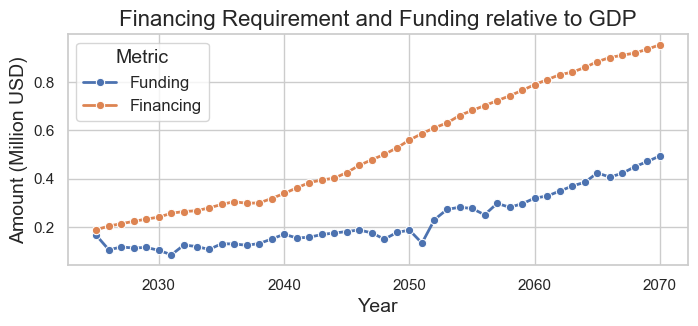

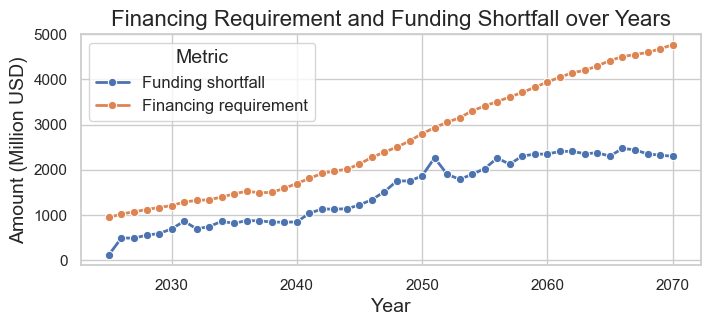

In [ ]:

# !/usr/local/bin/python3.11 -m pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_metric_time_series(df, selected_rows, title, xlabel="Year", ylabel="Amount (Million USD)", 
                              legend_title="Metric", fig_size=(8, 3)):
    """
    Plot a time series line chart for selected rows from a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The source DataFrame.
    selected_rows : list
        List of row labels to select (the DataFrame will be transposed).
    title : str
        The title of the plot.
    xlabel : str, default "Year"
        Label for the x-axis.
    ylabel : str, default "Amount (Million USD)"
        Label for the y-axis.
    legend_title : str, default "Metric"
        Title for the legend.
    fig_size : tuple, default (12, 6)
        The size of the figure.
    """
    # 1. Select the rows and transpose the DataFrame.
    df_plot = df.loc[selected_rows].T.reset_index().rename(columns={'index': 'Year'})
    
    # 2. Melt the DataFrame into long format.
    df_long = df_plot.melt(id_vars="Year", var_name="Metric", value_name="Value")
    
    # 3. Ensure the Year column is integer.
    df_long["Year"] = df_long["Year"].astype(int)
    
    # 4. Set seaborn style and create the plot.
    sns.set(style="whitegrid")
    plt.figure(figsize=fig_size)
    ax = sns.lineplot(data=df_long, x="Year", y="Value", hue="Metric", marker="o", linewidth=2)
    
    # 5. Set title and labels.
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    plt.legend(title=legend_title, fontsize=12, title_fontsize=14)
    plt.show()

# Example usage:
# Plot for GDP percentages:
plot_metric_time_series(gdp_percentage, 
                        selected_rows=["Funding", "Financing"], 
                        title="Financing Requirement and Funding relative to GDP")

# Plot for dashboard summary:
plot_metric_time_series(dashboard_summary, 
                        selected_rows=["Funding shortfall", "Financing requirement"], 
                        title="Financing Requirement and Funding Shortfall over Years")


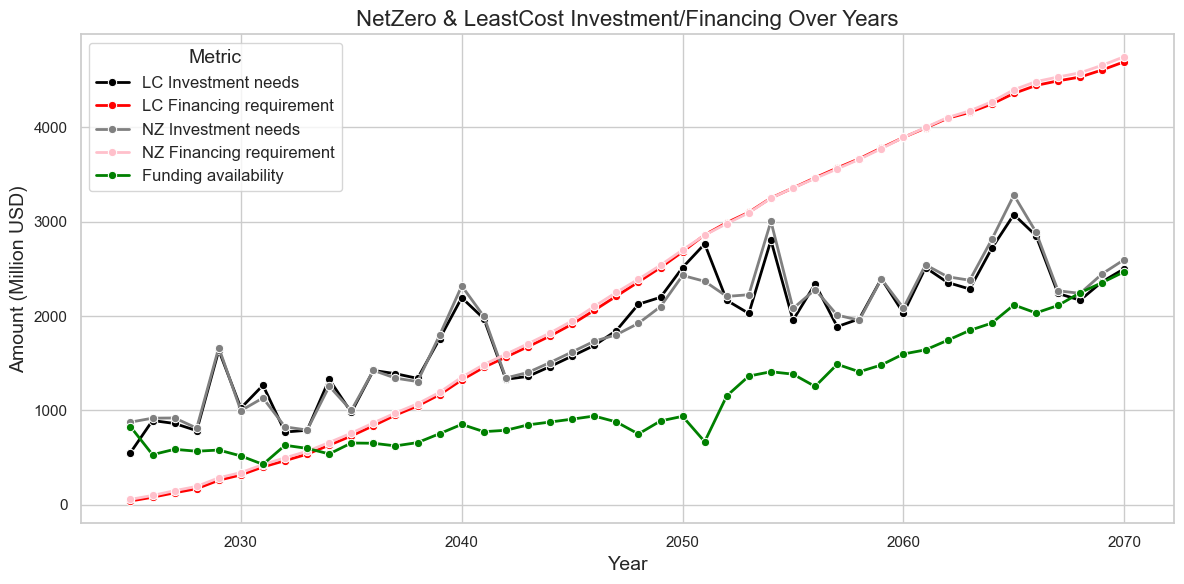

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume df_result structure is similar to:
#["NetZero Investment Needs (Million USD)", "NetZero Financing Requirements (Million USD)", ...]
# Columns: Years such as 2025, 2026, ...
# Each cell represents the value of the corresponding metric for that year

# 1. Select the 5 rows we need to plot, and transpose to make "Year" the row index
df_plot = pd.DataFrame({
                    "LC Investment needs": lc_needs.loc["Investment needs",:],
                    "LC Financing requirement": lc_needs.loc["Financing Requirements",:],
                    "NZ Investment needs": nz_needs.loc["Investment needs",:],
                    "NZ Financing requirement": nz_needs.loc["Financing Requirements",:],
                    "Funding availability": dashboard_summary.loc["Funding availability",:],
                })

# 2. Reset index and convert to long format for easier plotting with seaborn
df_plot = df_plot.reset_index().rename(columns={"index": "Year"})
df_long = df_plot.melt(id_vars="Year", var_name="Metric", value_name="Value")

# 如果 Year 是字符串，可以转成 int（若需要）
# df_long["Year"] = df_long["Year"].astype(int)

# 3. 设置 seaborn 样式并绘制
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# 自定义每条线对应的颜色（可根据喜好修改）
palette = {
    "LC Investment needs": "black",
    "LC Financing requirement": "red",
    "Funding availability": "green",
    "NZ Investment needs": "gray",
    "NZ Financing requirement": "pink",
}

ax = sns.lineplot(
    data=df_long,
    x="Year",
    y="Value",
    hue="Metric",
    palette=palette,
    marker="o",
    linewidth=2
)

# 4. Set title, axis labels, and legend
ax.set_title("NetZero & LeastCost Investment/Financing Over Years", fontsize=16)
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Amount (Million USD)", fontsize=14)
plt.legend(title="Metric", fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.show()



In [ ]:
!/usr/local/bin/python3.11 -m pip install plotly

import pandas as pd
import plotly.express as px

def plot_co2_emissions_scenarios(df_emissions):
    """
    Expects a DataFrame `df_emissions` with columns:
      - "Least Cost"
      - "Net Zero"
      - "Emissions Savings"
    and index as the Year (e.g., 2024..2069).
    
    Produces an interactive line chart showing each scenario's emissions
    over the years, with "Emissions Savings" as a dashed line.
    """
    # 1) Reset index so 'Year' becomes a column; rename columns for clarity
    df_plot = df_emissions.reset_index().rename(columns={"index": "Year"})
    
    # 2) Convert to long format for Plotly Express
    df_long = df_plot.melt(
        id_vars="Year", 
        var_name="Scenario", 
        value_name="Emissions"
    )
    
    # 3) Convert Year to int if necessary
    df_long["Year"] = df_long["Year"].astype(int)
    
    # 4) Create an interactive line chart
    fig = px.line(
        df_long,
        x="Year",
        y="Emissions",
        color="Scenario",
        title="Projected CO₂ Emissions by Scenario",
        labels={"Emissions": "Mt CO₂", "Year": "Year"},
    )
    
    # 5) Customize line styles and colors
    #    - 'Emissions Savings': dashed gray
    fig.update_traces(
        selector=dict(name="Emissions Savings"),
        line=dict(dash="dash", color="gray", width=2),
    )
    #    - 'Least Cost': blue
    fig.update_traces(
        selector=dict(name="Least Cost"),
        line=dict(color="blue", width=2),
    )
    #    - 'Net Zero': orange
    fig.update_traces(
        selector=dict(name="Net Zero"),
        line=dict(color="orange", width=2),
    )
    
    # Optional: use a white background
    fig.update_layout(template="plotly_white")
    
    fig.show()

# =======================
# EXAMPLE USAGE:
# =======================
df_emissions = pd.DataFrame({
    "Least Cost": least_cost_summary["co2_emission"],
    "Net Zero": net_zero_summary["co2_emission"],
    "Emissions Savings": -net_zero_summary["co2_emission"]+least_cost_summary["co2_emission"],
}, index=range(2025,2070,1))

plot_co2_emissions_scenarios(df_emissions)


The system cannot find the path specified.


In [ ]:
# df_funding_availability_full
# df_funding_availability_full.T
# !/opt/homebrew/bin/python3.12 -m pip install ipykernel -U --user --force-reinstall

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

width=800
height=600
years = list(dashboard_summary.columns)  # 2025, 2030, 2035, ..., 2070

# df_funding_plot = df_funding_availability_full.T.drop

df_funding_plot = pd.DataFrame({
    "Year": dashboard_summary.columns,
    "Government spending": list(df_funding_availability_full.loc["Government spending", :]),
    "Debt Write-off": list(df_funding_availability_full.loc["Debt Write-off", years]),
    "SOE internal cash generation": list(df_funding_availability_full.loc["SOE internal cash generation", years]),
    "Capital injection": list(df_funding_availability_full.loc["Capital Injection", years]),
    "International Project Grants": list(df_funding_availability_full.loc["International Project Grants", years]),
    "Additional Project Grants": list(df_funding_availability_full.loc["Additional Project Grants", years]),
    "Fossil Fuel Expenditure Savings": list(df_funding_availability_full.loc["Fossil Fuel Expenditure Savings", years]),
    "Carbon Credits": list(df_funding_availability_full.loc["Carbon Credits", years]),

    "Financing Requirement": dashboard_summary.loc["Financing requirement", years], 
    "Funding Availability": dashboard_summary.loc["Funding availability", years]
})

# df_funding_plot.head()
stacked_cols_funding = [
    "Government spending",
    "Debt Write-off",
    "SOE internal cash generation",
    "Capital injection",
    "International Project Grants",
    "Additional Project Grants",
    "Fossil Fuel Expenditure Savings",
    "Carbon Credits"
]

color_map = {
    "Government spending": "#ecf0a2",             # 浅黄色ecf0a2
    "Debt Write-off": "#ecf0a2",                  # 更深一点的浅黄
    "SOE internal cash generation": "#c4da4b",    # 浅青绿
    "Capital Injection": "#c4da4b",               # 黄绿色
    "International Project Grants": "#8bbf3e",    # 偏绿
    "Additional Project Grants": "#8bbf3e",       # 更亮绿
    "Fossil Fuel Expenditure Savings": "#00cc99", # 青绿色
    "Carbon Credits": "#008080"                   # 深青绿
}

def stacked_area_fig(df_stack_plot, stacked_cols,width=800,height=600,color_map=color_map,title="",line_plots=True):
    """
    Sankey stacked area chart
    """

    df_area = df_stack_plot.melt(
        id_vars="Year",
        value_vars=stacked_cols,
        var_name="Source",
        value_name="Value"
    )

    fig = px.area(
        df_area, x="Year", y="Value", color="Source",
        color_discrete_map=color_map,
        title=title,
        labels={"Value": "Million US$", "Year": "Year", "Source": ""},
        template="plotly_white"
    )
    if line_plots :
        # Financing Requirement: red
        fig.add_trace(
            go.Scatter(
                x=df_stack_plot["Year"],
                y=df_stack_plot["Financing Requirement"],
                mode="lines+markers",
                name="Financing Requirement",
                line=dict(color="red", width=2),
                marker=dict(color="red", size=5)
            )
        )
    # elif line_plots.lowercase() in ["funding availability","funding"]:
        # Funding Availability: darkgreen
        fig.add_trace(
            go.Scatter(
                x=df_stack_plot["Year"],
                y=df_stack_plot["Funding Availability"],
                mode="lines+markers",
                name="Funding Availability",
                line=dict(color="darkgreen", width=2),
                marker=dict(color="darkgreen", size=5)
            )
        )
    
    fig.update_layout(
        xaxis=dict(range=[2024, 2071], tickangle=-45),  
        # yaxis=dict(range=[0, 6000]),                   
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="center",
            x=0.2
        ),
        width=width,
        height=height
    )
    return fig
title = "Funding Availability"
fig = stacked_area_fig(df_funding_plot, stacked_cols_funding,width=800,height=600,color_map=color_map,title=title,line_plots=True)
fig.show()
# df_area

In [ ]:

# financing_sources
# df_financing_repayments
# df_financing_repayments

In [ ]:
import pandas as pd
import numpy as np

years = list(dashboard_summary.columns)  # 2025, 2030, 2035, ..., 2070

# df_funding_plot = df_funding_availability_full.T.drop

df_financing_plot = pd.DataFrame({
    "Year": dashboard_summary.columns,
    "Existing Financing Repayments": list(df_financing_repayments.loc["Existing finance payments (Million USD)", years]),
    "Financing payments for construction of new energy": list(df_financing_repayments.loc["Financing payments for construction of new energy", years]),
    "Fossil fuel retirement cost": list(df_financing_repayments.loc["Financing Payments for retirement of old fossil fuel technologies", years]),
    "Capital Injection Repayments": list(df_financing_repayments.loc["Capital Injection Repayment (Million USD)", years]),
    "Conc IFI (Debt)": list(nz_needs.loc["Debt: Conc_IFI", years]),
    "Conc DPS (Debt)": list(nz_needs.loc["Debt: Conc_DPS", years]),
    "Comm Intl (Debt)": list(nz_needs.loc["Debt: Comm_Intl", years]),
    "Comm Dom (Debt)": list(nz_needs.loc["Debt: Comm_Dom", years]),
    "Conc IFI (Equity)": list(nz_needs.loc["Equity: Conc_IFI", years]),
    "Conc DPS (Equity)": list(nz_needs.loc["Equity: Conc_DPS", years]),
    "Comm Intl (Equity)": list(nz_needs.loc["Equity: Comm_Intl", years]),
    "Comm Dom (Equity)": list(nz_needs.loc["Equity: Comm_Dom", years]),

    "Financing Requirement": dashboard_summary.loc["Financing requirement", years], 
    "Funding Availability": dashboard_summary.loc["Funding availability", years]
})

# df_funding_plot.head()
stacked_cols = [
    "Existing Financing Repayments",
    # "Financing payments for construction of new energy",
    # "Fossil fuel retirement cost",
    "Capital Injection Repayments",
    "Conc IFI (Debt)",
    "Conc DPS (Debt)",
    "Comm Intl (Debt)",
    "Comm Dom (Debt)",
    "Conc IFI (Equity)",
    "Conc DPS (Equity)",
    "Comm Intl (Equity)",
    "Comm Dom (Equity)",
    ]

color_map = {
    "Existing Financing Repayments": "#7F7F7F",      # mid-grey
    "Financing payments for construction of new energy": "#a6a6a6",       # light grey
    "Fossil fuel retirement cost": "#a6a6a6",             
    "Capital Injection Repayments": "#f2f2f2",       # Gold
    "Conc IFI (Debt)": "#eeb500",                    # Orange
    "Conc DPS (Debt)": "#ffca21",                    # Orange
    "Comm Intl (Debt)": "#ffe285",                   # Deep Orange
    "Comm Dom (Debt)": "#fff5d9",                    # Copper
    "Conc IFI (Equity)": "#1f4e79",                  # Light Blue
    "Conc DPS (Equity)": "#2e75b6",                  # Mid Blue
    "Comm Intl (Equity)": "#5b9bd5",                 # Light Blue
    "Comm Dom (Equity)": "#9dc3e6",                  # Light Blue
    "Financing Requirement": "#FF0000",              # Red (line)
    "Funding Availability": "#008000"                # Green (line)
}
title = "Financing"
fig = stacked_area_fig(df_financing_plot, stacked_cols,width=800,height=600,color_map=color_map,title=title,line_plots=True)
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)
def plot_funding_shortfall_bar_interactive(df, row_label="Funding shortfall", 
                                           title="Projected Funding Shortfall in Absolute Terms"):
    """
    Selects a specific row (row_label) from the DataFrame and treats the columns as years,
    then uses Plotly to generate an interactive bar chart.
    
    Parameters:
    ----------
    df : pandas.DataFrame
        The source data, containing multiple rows (indicators) and columns (years).
    row_label : str, default "Funding shortfall"
        The row label to plot.
    title : str, default "Projected Funding Shortfall in Absolute Terms"
        The chart title.
    """
    # Select that row and transpose it, making 'Year' a column, and rename the other value column as 'Value'"
    df_bar = df.loc[row_label,:].T.reset_index().rename(columns={'index': 'Year', row_label: 'Value'})
    data = {
    "Year": list(df_bar["Year"]),
    "Value": list(df_bar["Value"])
        }
    df_bar = pd.DataFrame(data)

    fig = px.bar(
        df_bar,
        x='Year',
        y='Value',
        title=title,
        labels={'Value': 'Million US$', 'Year': 'Year'}
    )

    fig.update_traces(marker_color='green')  # Set the bar chart to green
    fig.update_layout(
        template='plotly_white',  # White background style
        xaxis=dict(range=[df_bar['Year'].min(), df_bar['Year'].max()],title='Year'),
        yaxis=dict(title='Million US$')
    )

    fig.show()

# ====================
# Example Usage
# ====================
plot_funding_shortfall_bar_interactive(dashboard_summary, row_label="Funding shortfall")


In [ ]:

# incremental_investment
net_zero_summary.head()
# df_5yr_avg["delta_capital_cost"].values
# df_financing_needs_ffr
# df_category_sum_nz

,variable_cost,fixed_cost,annual_elec_production,co2_emission,carbon_price,capital_cost,total_cost,cost_of_elec_in_pj,cost_of_elec,cost_of_co2
2025,139.3078,224.812,335.7137,0.4391,67.060662,869.3439,1233.4637,3.674154,1.020598,29.446337
2026,83.7825,237.1475,349.8989,0.1041,68.569526,978.1743,1299.1043,3.712799,1.031333,7.138088
2027,118.2583,239.7243,367.1226,0.1982,70.112341,966.7791,1324.7617,3.608499,1.002361,13.896266
2028,115.9271,258.1946,389.7131,0.2378,71.689869,954.408,1328.5297,3.408994,0.946943,17.047851
2029,91.8448,285.0612,420.6769,0.1984,73.302891,1637.2812,2014.1872,4.787967,1.329991,14.543293


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

width = 800
height = 600
df_long_nz = df_category_sum_nz.melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
df_long_incremental = incremental_investment.melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
years = df_category_sum_nz["Year"]

# ==========  2 rows × 4 columns  ==========
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[
        "Plot 1: Investment Needs",       # Subplot 1 title
        "Plot 2: Cost of Capital",        # Subplot 2 title
        "Plot 3: Borrowed Sources",       # Subplot 3 title
        "Plot 4: Scenario Difference",    # Subplot 4 title
        "Plot 5: Future Needs by Source", # Subplot 5 title
        "Plot 6: Funding Shortfall",      # Subplot 6 title
        "Plot 7: Additional Metrics",     # Subplot 7 title
        "Plot 8: Another Metric"          # Subplot 8 title
    ]
)

color_map = {

    "Biomass": "#ff9900",       # Orange
    "Geothermal": "#66ccff",    # Light Blue
    "Solar PV": "#ffd700",      # Gold
    "Wind": "#66ff66",          # Light Green
    "Onshore Wind": "#66ff66",
    "Offshore Wind": "#66ff66",
    "Nuclear": "#999999",       # Gray
    "Coal": "#333333",          # Dark Gray
    "Gas": "#ff6666",           # Light Red
    "Oil": "#cc6600",           # Dark Orange

    "Hydropower": "#3399FF",    # Blue
    "CSP": "#FFB84D",           # Light Orange
    "Distribution": "#808080",  # Medium Gray
    "Transmission": "#9966FF",  # Purple
    "Other": "#BEBEBE"          # Silver Gray
}
df_long_nz['Year'] = df_long_nz['Year'].astype(int).astype(str)

fig_area1 = px.area(
    df_long_nz, 
    x="Year", 
    y="InvestmentNeed", 
    color="Technology", 
    color_discrete_map=color_map,
    title="Projected Investment Needs to Reach Net Zero by 2050",
    labels={"InvestmentNeed": "Million US$", "Year": "Year"}
)
fig_area1.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

fig_area2  = px.bar(
    df_long_incremental, 
    x="Year",
    y="InvestmentNeed",
    color="Technology",
    color_discrete_map=color_map,
    barmode="relative", 
    title="Additional Capital Cost of Net Zero",
    labels={"Cost": "Million US$", "Year": "Year"}
)

fig_area2.update_layout(
    template="plotly_white",
    xaxis=dict(range=[2024.5, 2070.5]),
    # yaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor="black")
    width=width,
    height=height
)
fig_area2.update_layout(
    template="plotly_white",    
    )


df_cost = pd.DataFrame({
    "Scenario": ["NetZero", "NetZero", "NetZero"],
    "Cost Type": ["Capital Cost", "O&M Costs (Variable)", "O&M Costs (Fixed)"],
    "Value": [
        net_zero_summary["capital_cost"].sum(),
        net_zero_summary["variable_cost"].sum(),
        net_zero_summary["fixed_cost"].sum()
        ]  # Million US$
    })

fig_area3 = px.bar(
    df_cost,
    x="Scenario",
    y="Value",
    color="Cost Type",
    barmode="relative",  
    title="Total Undiscounted Scenario Cost 2025 to 2070",
    labels={"Value": "Million US$", "Scenario": ""}
)

fig_area3.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

df_diff = pd.DataFrame({
    "Year": df_5yr_avg["Year"],
    "Capital Cost":  list(df_5yr_avg["delta_capital_cost"].values),
    "Variable Cost": list(df_5yr_avg["delta_variable_cost"].values),
    "Fixed Cost":    list(df_5yr_avg["delta_fixed_cost"].values),
    "Cost of Carbon":list(df_5yr_avg["emission_saving"].values),
    # "Net Benefits":  df_5yr_avg["delta_capital_cost"]
})
# df_diff = pd.DataFrame({
#     "Year": df_5yr_avg["Year"],
#     "Capital Cost": list(df_5yr_avg["delta_capital_cost"].values),
#     "Variable Cost": [0,   20, 8,   0,   30,  0,   0,   0,   0  ],
#     "Fixed Cost":    [0,   0,  7,   0,   0,   0,   0,   0,   0  ],
#     "Cost of Carbon":[0,   0,  0,   30,  37,  40,  50,  60,  70 ],
#     "Net Benefits":  [-46, 20, 15, 47,  67, 107, 221, 275, 370]
# })
df_diff_long= df_diff.melt(
    id_vars=["Year"],  
    value_vars=["Capital Cost", "Variable Cost", "Fixed Cost", "Cost of Carbon"],
    var_name="Cost Type",
    value_name="Value"
)
df_diff["Net Benefits"] = df_diff["Capital Cost"] + df_diff["Variable Cost"] + df_diff["Fixed Cost"] + df_diff["Cost of Carbon"]

color_map_costs = {

    "Cost of Carbon": "#66ff66",          # Light Green

    "Variable Cost": "#cc6600",           # Dark Orange

    "Capital Cost": "#3399FF",    # Blue
    "Fixed Cost":    "#66ccff"   # Light Blue
}
# stacked bar chart
fig_area4 = px.bar(
    df_diff_long,
    x="Year",
    y="Value",
    color="Cost Type",
    color_discrete_map=color_map_costs,
    barmode="relative",  
    title="Differential benefits and costs of NZ vs BAU (Million US$)",
    labels={"Value": "Million US$", "Year": "Year"}
)
fig_area4.add_trace(
    go.Scatter(
        x=df_diff["Year"],           
        y=df_diff["Net Benefits"],   # Net Benefits
        mode="markers+text",    
        text=df_diff["Net Benefits"].apply(lambda x: f"{round(x)}").astype(str),  
        textposition="top center",            
        marker=dict(
            symbol=141,       # horizontal line symbol 'line-ew', 141, '141'
            size=20,                # the length of the line is determined by size
            color="red",
        ),
        name="Net Benefits"     
    )
)
fig_area4.update_layout(
    template="plotly_white",
    showlegend=True,
    xaxis=dict(range=[2020.5, 2070.5]),
    width=width,
    height=height
    )


# 1) data 
df_stranded_cost = pd.DataFrame({
    "Fuel": ["Coal", "Gas", "Oil"],
    "Extra Stranded Cost": [0, 0, 0]  # initialised with 0, will be updated later
})
since_year = 2025
for tech in  df_stranded_cost["Fuel"]:
    # Calculate cumulative stranded costs from since_year
    df_stranded_cost.loc[df_stranded_cost["Fuel"]==tech, "Extra Stranded Cost"]=df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,(tech,tech)].sum()
# 2) Draw a bar chart
fig_stranded_cost = px.bar(
    df_stranded_cost,
    x="Fuel",
    y="Extra Stranded Cost",
    title="Extra Stranded Cost Compensation of Net Zero",
    labels={"Extra Stranded Cost": "Million US$", "Fuel": ""},
    text="Extra Stranded Cost"  # show values on the bar
)

# 3) customise layout
fig_stranded_cost.update_layout(
    template="plotly_white",
    yaxis=dict(range=[0, 800]),  # adjust the upper limit based on the data
    width=width,
    height=height
    )

fig_stranded_cost.update_traces(textposition="outside")
####################################
# Calculate only the total stranded costs for coal, natural gas and oil
stranded_cost = df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,("Total","Total")].copy()
    
df_plot = pd.DataFrame({
    "Year": df_category_sum_nz["Year"],
    "Net Zero Financing Needs": df_category_sum_nz.copy().drop('Year', axis=1).sum(axis=1),
    "Stranded Cost Compensation": list(stranded_cost)
})
# Convert both columns to the same data type (float)
df_plot["Net Zero Financing Needs"] = df_plot["Net Zero Financing Needs"].astype(float)
df_plot["Stranded Cost Compensation"] = df_plot["Stranded Cost Compensation"].astype(float)

fig_needs_by_source = px.bar(
    df_plot,
    x="Year",
    y=["Net Zero Financing Needs", "Stranded Cost Compensation"],
    barmode="relative",
    color_discrete_sequence=["grey", "black"],
    title="Future Investment Needs by Source",
    labels={"value": "Million US$", "variable": ""},  # adjust the legend/axis labels
    template="plotly_white",
)

# add black border to all bars
fig_needs_by_source.update_traces(marker=dict(line=dict(color="black", width=1)))

# adjust layout, e.g. move the legend below, change the width and height
fig_needs_by_source.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15,  # legend below
        xanchor="center",
        x=0.5
    ),
    xaxis=dict(range=[2024, 2070.5]),
    
    width=width,
    height=height
)

df = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["cost_of_elec"],
    "LeastCost": least_cost_summary["cost_of_elec"],
})

# melt NetZero and LeastCost into "Scenario" and "Cost" two columns
df_long_elec_cost = df.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)
# now the structure of df_long is similar to:
#   Year   Scenario   Cost
# 0 2025   NetZero    14
# 1 2030   NetZero    15
# 2 2035   NetZero    12
# ... 
# . 2025   LeastCost  14

fig_elec_cost = px.line(
    df_long_elec_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Average Cost of Electricity US$/TWh",
    labels={"Cost": "US$/TWh", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  # customise colors
)

fig_elec_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # according to your data range, or let Plotly decide
    width=width,
    height=height
)


df_capital = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["capital_cost"],
    "LeastCost": least_cost_summary["capital_cost"],
})

# melt NetZero and LeastCost into "Scenario" and "Cost" two columns
df_capital_cost = df_capital.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)

fig_capital_cost = px.line(
    df_capital_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Capital Cost NZ vs LC",
    labels={"Cost": "Million US$", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  
)

fig_capital_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # according to your data range, or let Plotly decide
    width=width,
    height=height
)


fig.update_layout(template="plotly_white")
fig_area1.show()
# fig_area2.show()
# fig_area3.show()
# fig_area4.show()
# fig_stranded_cost.show()
# fig_needs_by_source.show()
# fig_elec_cost.show()
# fig_capital_cost.show()
# df_long_nz.head(300)


### Here we save the figures 
- In both HTML and .png

### Example usage for the functions:
>
```python
# Import the figure saving utilities
from save_figure import save_figure, save_all_figures

# Basic usage - single line per figure
save_figure(fig_area1)  # Uses figure title as filename
save_figure(fig_area2, custom_name="investment_by_tech") 
save_figure(fig_area3, save_png=False)  # HTML only

# Save to a different directory
save_figure(fig_elec_cost, output_dir="important_figures")

# Save all figures at once
figs = {"area1": fig_area1, "area2": fig_area2, "needs": fig_needs_by_source}
save_all_figures(figs)  # Uses dict keys as filenames

#or 
figs = [fig_area1, fig_area2, fig_needs_by_source]
save_all_figures(figs)  # Uses figure titles as filenames
```

In [ ]:
# Create figures directory if it doesn't exist
import os
# os.makedirs("figures", exist_ok=True)
from MinFin.save_figure import save_figure, save_all_figures

# Save all figures at once (as a list)
all_figures = [fig_area1, fig_area2, fig_area3, fig_area4, 
               fig_stranded_cost, fig_needs_by_source, 
               fig_elec_cost, fig_capital_cost]
save_all_figures(all_figures)


Saved HTML: minfin_output/figures\Projected_Investment_Needs_to_Reach_Net_Zero_by_2050.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Additional_Capital_Cost_of_Net_Zero.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Total_Undiscounted_Scenario_Cost_2025_to_2070.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Differential_benefits_and_costs_of_NZ_vs_BAU_(Million_US$).html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Extr

### Funding Availability Projections

This section analyzes historical and projected funding sources for energy investments:

1. **Data Preparation**:
   - Extracts yearly funding data from `df_funding_envelope`
   - Creates a structured DataFrame with three key funding sources

2. **Visualization**:
   - Creates a bar chart showing historical funding sources by year
   - Generates a stacked area chart displaying future funding projections
   - Uses custom colors to differentiate between funding sources

3. **Output**:
   - Both visualizations help identify funding trends and potential gaps
   - Automatically saves figures to the `figures` directory for later use

The `save_all_figures()` function at the end preserves both visualizations as interactive HTML and static PNG files.

In [ ]:
# df_funding_envelope.index

In [ ]:
import plotly.express as px
year_idx = [x for x in df_funding_envelope.index
 if isinstance(x, (int, float))]
df_funding_historic_plot = df_funding_envelope.loc[year_idx]

df_funding = pd.DataFrame({
    "Year": year_idx,  
    "Government Spending": list(df_funding_historic_plot["Budget"]),
    "SOE internal cash generation":  list(df_funding_historic_plot["SOE Gen."]),
    "International Grants":  list(df_funding_historic_plot["Grant"])
})
fig = px.bar(
    df_funding,
    x="Year",
    y=["Government Spending", "SOE internal cash generation", "International Grants"],
    barmode="relative",  
    title="Historic Sources of Funding Availability for Energy Investments",
    labels={"value": "Million US$", "variable": ""},  
    template="plotly_white",
    color_discrete_sequence=["#fcfab2","#c4b97a", "#d7ea64" ]
)

fig.update_layout(
    xaxis=dict(dtick=1),  
    yaxis=dict(range=[0, 800]),  
    width=width,
    height=height,
    legend=dict(
    orientation="h",   
    yanchor="bottom",
    y=-0.2,            
    xanchor="center",
    x=0.5             
    )
)

fig.show()
fig_funding_projection = stacked_area_fig(df_funding_plot, stacked_cols_funding,width=800,height=600,color_map=color_map,title=title,line_plots=0)
fig_funding_projection.show()
save_all_figures([fig,fig_funding_projection])

Saved HTML: minfin_output/figures\Historic_Sources_of_Funding_Availability_for_Energy_Investments.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Saved HTML: minfin_output/figures\Financing.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Historic Financing (2010-2024)
This section analyzes the composition of historical energy investment financing from 2010-2024, breaking down funding sources across multiple dimensions:

1 Organization:
> Provider: Public vs. Private sector contributions
> 
> Instrument: Debt vs. Equity financing proportions
> 
> Origin: Domestic vs. International funding sources
> 
> Source: Detailed breakdown by specific financing entities

2 Data:
> Extracts relevant data from financing datasets
> 
> Combines different categories into a unified structure
> 
> Converts wide-format data to long-format for visualization

In [ ]:
institution_shares #= fbs.get_institution_shares()
financing_sector_shares #= fbs.get_financing_sector_shares()
# repayment_statistics
hd.get_financing_source_shares()


,Historical,Projected
Conc_IFI,0.743813,0.743813
Conc_DPS,0.111098,0.111098
Comm_Intl,0.121813,0.121813
Comm_Dom,0.023275,0.023275


In [ ]:
df_provider = financing_sector_shares.loc[["Public", "Private"],:].T
df_instrument = repayment_statistics.loc[("Summary","Total financing volumes"),["Debt Share", "Equity Share"]].T
df_source =hd.get_financing_source_shares().loc[:,"Historical"].to_frame().T
df_source

,Conc_IFI,Conc_DPS,Comm_Intl,Comm_Dom
Historical,0.743813,0.111098,0.121813,0.023275


In the following cell we
> - Create a horizontal stacked bar chart showing percentage distributions
> - Displays each financing dimension as a separate category
> - Uses custom colors to distinguish between subcategories

In [ ]:
import pandas as pd

df_provider = financing_sector_shares.loc[["Public", "Private"],:].T
df_instrument = repayment_statistics.loc[("Summary","Total financing volumes"),["Debt Share", "Equity Share"]].to_frame().T
df_origin = financing_sector_shares.loc[["Domestic", "International"],:].T
df_source = hd.get_financing_source_shares().loc[:,"Historical"].to_frame().T

df_provider["Category"] = "Provider"
df_instrument["Category"] = "Instrument"
df_origin["Category"] = "Origin"
df_source["Category"] = "Source"

# Merge 4 dataframes
df_wide = pd.concat([df_provider, df_instrument, df_origin, df_source], ignore_index=True)

df_long = df_wide.melt(
    id_vars="Category",
    var_name="Subcategory",
    value_name="Value"
)

# If some rows have NaN (e.g. because they don't exist in the original data), discard them
df_long = df_long.dropna(subset=["Value"]).reset_index(drop=True)

import plotly.express as px
# color_map = {
#     "Conc IFI": "#99CCFF",
#     "Conc DPS": "#FFCC99",
#     "Comm Intl": "#FF9999",
#     "Comm Dom": "#FFFF99",
#     "Domestic": "#FFCC66",
#     "International": "#66CC99",
#     "Debt": "#99FF99",
#     "Equity": "#66CC66",
#     "Public": "#CCCCFF",
#     "Private": "#CC99FF"
# }

fig = px.bar(
    df_long,
    x="Value",
    y="Category",
    color="Subcategory",
    text="Subcategory",
    orientation="h",
    barmode="relative",  # stack
    color_discrete_map=color_map,
    title="Historic Sources of Finance for Energy Investments 2010-2024",
    labels={"Value": "Percentage (%)", "Category": ""}
)
fig.update_traces(
    # ,      
    textposition="inside",    # put text inside the bar
    insidetextanchor="middle" # center the text vertically
)

fig.update_xaxes(range=[0, 1])

fig.update_layout(
    template="plotly_white",
    showlegend = False,
    width = width,
    height = height,
    # margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()
save_figure(fig)

Saved HTML: minfin_output/figures\Historic_Sources_of_Finance_for_Energy_Investments_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



{'html': 'minfin_output/figures\\Historic_Sources_of_Finance_for_Energy_Investments_2010-2024.html'}

In [ ]:
# repayment_statistics

In [ ]:
import plotly.graph_objects as go
import pandas as pd
volume={"Conc_IFI": 0,
    "Conc_DPS":  0,
    "Comm_Intl":  0,
    "Comm_Dom":   0}
df_raw = pd.DataFrame({
    "MarketElement": list(repayment_statistics.loc[("Debt",list(volume.keys())),"Market Element"]),
    "volume": list(repayment_statistics.loc[("Debt",list(volume.keys())),"Volume (USD)"]),
    "color": ["#ffbbbc", "#ff7b7b", "#ff0000", "#c00000"]
},index=volume.keys())

df_sorted = df_raw.sort_values("MarketElement")
df_plot = df_sorted.copy()


base = df_raw.loc[:,"volume"].cumsum()-df_raw.loc[:,"volume"]

fig = go.Figure()

a = df_plot.loc[:,"volume"].cumsum()
for key, v in volume.items():
    y_val = df_plot.loc[key,"MarketElement"]
    x_val = df_plot.loc[key,"volume"]#+base[key]
    # print([y_val])
    fig.add_trace(
        go.Bar(
            x=[x_val],         
            y=[y_val],
            base= base[key],
            orientation="h",
            marker_color=df_plot.loc[key,"color"],
            name=key,
            width=y_val,              
            offset=-y_val              # offset 0.15, align the down edge of the bar to y_val
        )
    )

fig.update_layout(
    title="Merit order of Financing Sources by Grant Element between 2010-2024",
    showlegend=True,
    barmode="relative",   
    xaxis=dict(title="Amount ($)", range=[0, 9000]),
    yaxis=dict(title="Market Element", range=[0,1], zeroline=True),
    template="plotly_white",
    width=width,
    height=height
)
save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Merit_order_of_Financing_Sources_by_Grant_Element_between_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Financial Institution Contributions Analysis (2010-2024)

This section visualizes the proportional contributions from different financial institutions to energy investments during 2010-2024:

1. **Data Preparation**:
   - Organizes institution contribution data into plotting format
   - Adds empty placeholder column for proper horizontal display

2. **Custom Visualization Function**:
   - Implements a reusable `single_bar_plot()` function for horizontal stacked bars
   - Handles percentage formatting when values are between 0-1
   - Positions the legend horizontally at the bottom for better readability

3. **Output**:
   - Displays the relative contribution of each financial institution
   - Shows the historic proportion of funding from each source
   - Helps identify the most significant financial contributors

The visualization provides insights into which institutions have historically played the largest roles in financing energy investments.

In [ ]:
# institution_shares

In [ ]:
color_map = {
    "Bilateral Agency": "#7f6000",
    "Multilateral Agency": "#bf9000",
    "Foreign Government": "#ffc000",
    "National Government": "#ffd966",
    "Domestic Public Sector": "#ffe699",
    "Climate Funds": "#fff2cc",
    "Commercial Bank": "#2f5597",
    "Private Equity Fund": "#4472c4"
}
df_institution_shares_plot = pd.DataFrame({
    "Financier": institution_shares.index,
    "Share": institution_shares["Share"]
})
df_institution_shares_plot[""] = ""

def single_bar_plot(df_plot, x, y, color_map, title="", labels="",width=800,height=600):
    fig = px.bar(
        df_plot,
        x=x,
        y=y,
        color="Financier",
        orientation="h",
        barmode="stack",
        color_discrete_map=color_map,
        title=title,
        # labels={"Share": "Percentage", "Row": ""}
    )
    if max(df_plot[x]) <1:
        fig.update_layout(
            xaxis=dict(range=[0,1], tickformat=".0%"),
            width=width,
            height = height,
            legend=dict(
                orientation="h",   # 水平排列
                yanchor="bottom",
                y=-0.3,            # 图例相对于整个图表的纵向位置（可根据需要调整）
                xanchor="center",
                x=0.5              # 图例居中
                )   
        )
    else:
        fig.update_layout(
            width=width,
            height = height,
            legend=dict(
                orientation="h",   # 水平排列
                yanchor="bottom",
                y=-0.3,            # 图例相对于整个图表的纵向位置（可根据需要调整）
                xanchor="center",
                x=0.5              # 图例居中
                )   
        )
    return fig
fig = single_bar_plot(df_institution_shares_plot, "Share", "", color_map, "Historic Proportion of Contributions from Financier 2010-2024", {"Share": "Percentage", "Row": ""})
save_figure(fig)
fig.show()

Saved HTML: minfin_output/figures\Historic_Proportion_of_Contributions_from_Financier_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Historical Financing Sources Visualisation

This section analyzes the breakdown of financing by source type and financial instrument (debt vs. equity; Domestic vs. international):

1. **Data Extraction**:
   - Identifies four key financing source types: Concessional IFI, Concessional DPS, Commercial International, and Commercial Domestic
   - Extracts volume data for both debt and equity instruments across these sources
   - Combines source type and instrument into unified categories (e.g., "Conc_IFI (Debt)")

2. **Visualization Preparation**:
   - Creates a custom color scheme to distinguish between different financing sources
   - Calculates percentage shares for relative comparison
   - Prepares data for horizontal bar chart visualization

3. **Multiple Views**:
   - First chart shows the relative share (percentage) of each financing source-instrument combination
   - Second chart presents the absolute volumes in USD
   - Both visualizations use the same color scheme for consistency

In [ ]:
repayment_statistics
types = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
df_new = repayment_statistics.loc[(["Debt","Equity"],types),"Volume (USD)"]
# df_new = df_new.rename(columns={"value": "Amount"})

In [ ]:
types = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
df_source_share = repayment_statistics.loc[(["Debt","Equity"],types),"Volume (USD)"]

df_source_share = df_source_share.reset_index() # reset multi-level index to single level
#  ["level_0", "level_1", "value"]

df_source_share["merged"] = df_source_share["level_1"] + " (" + df_source_share["level_0"] + ")"

color_map_source_share = ["#7f6000", "#bf9000", "#ffc000","#ffd966","#ffe699","#fff2cc","#2f5597","#4472c4"]
color_map_source_share = {k:v for k,v in zip(df_source_share["merged"].unique(), color_map_source_share)}

df_source_share_plot = pd.DataFrame({
    "Financier": df_source_share["merged"],
    "Share": df_source_share["Volume (USD)"]/df_source_share["Volume (USD)"].sum()
})
df_source_share_plot[""] = ""
fig = single_bar_plot(df_source_share_plot, "Share", "", color_map_source_share, "Historic Proportion of Contributions from Different Sources 2010-2024", {"Share": "Percentage", "Row": ""})

save_figure(fig)
fig.show()

df_source_share_plot = pd.DataFrame({
    "Financier": df_source_share["merged"],
    "Share": df_source_share["Volume (USD)"]
})
df_source_share_plot[""] = ""
fig = single_bar_plot(df_source_share_plot, "Share", "", color_map_source_share,  "Historic Proportion of Contributions from Different Sources 2010-2024", {"Share": "Percentage", "Row": ""})

save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Historic_Proportion_of_Contributions_from_Different_Sources_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Historic_Proportion_of_Contributions_from_Different_Sources_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [ ]:
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.405901,0.286073,0.990458,0.009542
Multilateral Agency,0.317207,0.209471,0.988280,0.011720
Foreign Government,0.016177,0.093944,1.000000,0.000000
National Government,0.100719,0.434034,0.144891,0.855109
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.023221,0.480228,0.791228,0.208772
Commercial Bank,0.031322,0.549836,1.000000,0.000000
Private Equity Fund,0.105453,1.000000,0.096183,0.903817


### Market element visualisation

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

width = 800
height = 600
df_long_nz = df_category_sum_nz.melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
df_long_incremental = incremental_investment.melt(
    id_vars="Year", 
    var_name="Technology", 
    value_name="InvestmentNeed"
)
years = df_category_sum_nz["Year"]

# ==========  2 rows × 4 columns  ==========
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[
        "Plot 1: Investment Needs",       # Subplot 1 title
        "Plot 2: Cost of Capital",        # Subplot 2 title
        "Plot 3: Borrowed Sources",       # Subplot 3 title
        "Plot 4: Scenario Difference",    # Subplot 4 title
        "Plot 5: Future Needs by Source", # Subplot 5 title
        "Plot 6: Funding Shortfall",      # Subplot 6 title
        "Plot 7: Additional Metrics",     # Subplot 7 title
        "Plot 8: Another Metric"          # Subplot 8 title
    ]
)

color_map = {

    "Biomass": "#ff9900",       # Orange
    "Geothermal": "#66ccff",    # Light Blue
    "Solar PV": "#ffd700",      # Gold
    "Wind": "#66ff66",          # Light Green
    "Onshore Wind": "#66ff66",
    "Offshore Wind": "#66ff66",
    "Nuclear": "#999999",       # Gray
    "Coal": "#333333",          # Dark Gray
    "Gas": "#ff6666",           # Light Red
    "Oil": "#cc6600",           # Dark Orange

    "Hydropower": "#3399FF",    # Blue
    "CSP": "#FFB84D",           # Light Orange
    "Distribution": "#808080",  # Medium Gray
    "Transmission": "#9966FF",  # Purple
    "Other": "#BEBEBE"          # Silver Gray
}
df_long_nz['Year'] = df_long_nz['Year'].astype(int).astype(str)

fig_area1 = px.area(
    df_long_nz, 
    x="Year", 
    y="InvestmentNeed", 
    color="Technology", 
    color_discrete_map=color_map,
    title="Projected Investment Needs to Reach Net Zero by 2050",
    labels={"InvestmentNeed": "Million US$", "Year": "Year"}
)
fig_area1.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

fig_area2  = px.bar(
    df_long_incremental, 
    x="Year",
    y="InvestmentNeed",
    color="Technology",
    color_discrete_map=color_map,
    barmode="relative", 
    title="Additional Capital Cost of Net Zero",
    labels={"Cost": "Million US$", "Year": "Year"}
)

fig_area2.update_layout(
    template="plotly_white",
    xaxis=dict(range=[2024.5, 2070.5]),
    # yaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor="black")
    width=width,
    height=height
)
fig_area2.update_layout(
    template="plotly_white",    
    )


df_cost = pd.DataFrame({
    "Scenario": ["NetZero", "NetZero", "NetZero"],
    "Cost Type": ["Capital Cost", "O&M Costs (Variable)", "O&M Costs (Fixed)"],
    "Value": [
        net_zero_summary["capital_cost"].sum(),
        net_zero_summary["variable_cost"].sum(),
        net_zero_summary["fixed_cost"].sum()
        ]  # Million US$
    })

fig_area3 = px.bar(
    df_cost,
    x="Scenario",
    y="Value",
    color="Cost Type",
    barmode="relative",  
    title="Total Undiscounted Scenario Cost 2025 to 2070",
    labels={"Value": "Million US$", "Scenario": ""}
)

fig_area3.update_layout(
    template="plotly_white",
    showlegend=True,
    width=width,
    height=height
    )

df_diff = pd.DataFrame({
    "Year": df_5yr_avg["Year"],
    "Capital Cost":  list(df_5yr_avg["delta_capital_cost"].values),
    "Variable Cost": list(df_5yr_avg["delta_variable_cost"].values),
    "Fixed Cost":    list(df_5yr_avg["delta_fixed_cost"].values),
    "Cost of Carbon":list(df_5yr_avg["emission_saving"].values),
    # "Net Benefits":  df_5yr_avg["delta_capital_cost"]
})
# df_diff = pd.DataFrame({
#     "Year": df_5yr_avg["Year"],
#     "Capital Cost": list(df_5yr_avg["delta_capital_cost"].values),
#     "Variable Cost": [0,   20, 8,   0,   30,  0,   0,   0,   0  ],
#     "Fixed Cost":    [0,   0,  7,   0,   0,   0,   0,   0,   0  ],
#     "Cost of Carbon":[0,   0,  0,   30,  37,  40,  50,  60,  70 ],
#     "Net Benefits":  [-46, 20, 15, 47,  67, 107, 221, 275, 370]
# })
df_diff_long= df_diff.melt(
    id_vars=["Year"],  
    value_vars=["Capital Cost", "Variable Cost", "Fixed Cost", "Cost of Carbon"],
    var_name="Cost Type",
    value_name="Value"
)
df_diff["Net Benefits"] = df_diff["Capital Cost"] + df_diff["Variable Cost"] + df_diff["Fixed Cost"] + df_diff["Cost of Carbon"]

color_map_costs = {

    "Cost of Carbon": "#66ff66",          # Light Green

    "Variable Cost": "#cc6600",           # Dark Orange

    "Capital Cost": "#3399FF",    # Blue
    "Fixed Cost":    "#66ccff"   # Light Blue
}
# stacked bar chart
fig_area4 = px.bar(
    df_diff_long,
    x="Year",
    y="Value",
    color="Cost Type",
    color_discrete_map=color_map_costs,
    barmode="relative",  
    title="Differential benefits and costs of NZ vs BAU (Million US$)",
    labels={"Value": "Million US$", "Year": "Year"}
)
fig_area4.add_trace(
    go.Scatter(
        x=df_diff["Year"],           
        y=df_diff["Net Benefits"],   # Net Benefits
        mode="markers+text",    
        text=df_diff["Net Benefits"].apply(lambda x: f"{round(x)}").astype(str),  
        textposition="top center",            
        marker=dict(
            symbol=141,       # horizontal line symbol 'line-ew', 141, '141'
            size=20,                # the length of the line is determined by size
            color="red",
        ),
        name="Net Benefits"     
    )
)
fig_area4.update_layout(
    template="plotly_white",
    showlegend=True,
    xaxis=dict(range=[2020.5, 2070.5]),
    width=width,
    height=height
    )


# 1) data 
df_stranded_cost = pd.DataFrame({
    "Fuel": ["Coal", "Gas", "Oil"],
    "Extra Stranded Cost": [0, 0, 0]  # initialised with 0, will be updated later
})
since_year = 2025
for tech in  df_stranded_cost["Fuel"]:
    # Calculate cumulative stranded costs from since_year
    df_stranded_cost.loc[df_stranded_cost["Fuel"]==tech, "Extra Stranded Cost"]=df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,(tech,tech)].sum()
# 2) Draw a bar chart
fig_stranded_cost = px.bar(
    df_stranded_cost,
    x="Fuel",
    y="Extra Stranded Cost",
    title="Extra Stranded Cost Compensation of Net Zero",
    labels={"Extra Stranded Cost": "Million US$", "Fuel": ""},
    text="Extra Stranded Cost"  # show values on the bar
)

# 3) customise layout
fig_stranded_cost.update_layout(
    template="plotly_white",
    yaxis=dict(range=[0, 800]),  # adjust the upper limit based on the data
    width=width,
    height=height
    )

fig_stranded_cost.update_traces(textposition="outside")
####################################
# Calculate only the total stranded costs for coal, natural gas and oil
stranded_cost = df_financing_needs_ffr.loc[df_financing_needs_ffr.index >= since_year,("Total","Total")].copy()
    
df_plot = pd.DataFrame({
    "Year": df_category_sum_nz["Year"],
    "Net Zero Financing Needs": df_category_sum_nz.copy().drop('Year', axis=1).sum(axis=1),
    "Stranded Cost Compensation": list(stranded_cost)
})
# Convert both columns to the same data type (float)
df_plot["Net Zero Financing Needs"] = df_plot["Net Zero Financing Needs"].astype(float)
df_plot["Stranded Cost Compensation"] = df_plot["Stranded Cost Compensation"].astype(float)

fig_needs_by_source = px.bar(
    df_plot,
    x="Year",
    y=["Net Zero Financing Needs", "Stranded Cost Compensation"],
    barmode="relative",
    color_discrete_sequence=["grey", "black"],
    title="Future Investment Needs by Source",
    labels={"value": "Million US$", "variable": ""},  # adjust the legend/axis labels
    template="plotly_white",
)

# add black border to all bars
fig_needs_by_source.update_traces(marker=dict(line=dict(color="black", width=1)))

# adjust layout, e.g. move the legend below, change the width and height
fig_needs_by_source.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.15,  # legend below
        xanchor="center",
        x=0.5
    ),
    xaxis=dict(range=[2024, 2070.5]),
    
    width=width,
    height=height
)

df = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["cost_of_elec"],
    "LeastCost": least_cost_summary["cost_of_elec"],
})

# melt NetZero and LeastCost into "Scenario" and "Cost" two columns
df_long_elec_cost = df.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)
# now the structure of df_long is similar to:
#   Year   Scenario   Cost
# 0 2025   NetZero    14
# 1 2030   NetZero    15
# 2 2035   NetZero    12
# ... 
# . 2025   LeastCost  14

fig_elec_cost = px.line(
    df_long_elec_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Average Cost of Electricity US$/TWh",
    labels={"Cost": "US$/TWh", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  # customise colors
)

fig_elec_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # according to your data range, or let Plotly decide
    width=width,
    height=height
)


df_capital = pd.DataFrame({
    "Year": net_zero_summary.index,
    "NetZero": net_zero_summary["capital_cost"],
    "LeastCost": least_cost_summary["capital_cost"],
})

# melt NetZero and LeastCost into "Scenario" and "Cost" two columns
df_capital_cost = df_capital.melt(
    id_vars="Year",
    var_name="Scenario",
    value_name="Cost"
)

fig_capital_cost = px.line(
    df_capital_cost,
    x="Year",
    y="Cost",
    color="Scenario",
    title="Capital Cost NZ vs LC",
    labels={"Cost": "Million US$", "Year": "Year", "Scenario": ""},
    color_discrete_map={"NetZero": "green", "LeastCost": "aqua"}  
)

fig_capital_cost.update_layout(
    template="plotly_white",
    # yaxis=dict(range=[0, 20]),  # according to your data range, or let Plotly decide
    width=width,
    height=height
)


fig.update_layout(template="plotly_white")
fig_area1.show()
# fig_area2.show()
# fig_area3.show()
# fig_area4.show()
# fig_stranded_cost.show()
# fig_needs_by_source.show()
# fig_elec_cost.show()
# fig_capital_cost.show()
# df_long_nz.head(300)


In [ ]:

def plot_market_element_by_financier(df, color_map,
                                           title="Market Elements of Finance for Energy Investments 2010-2024 by Financier"):
    """
    From a DataFrame, select a specific row (row_label) and treat it as a column of years,
    then use Plotly to generate an interactive bar chart.
    
    Params:
    ----------
    df : pandas.DataFrame
        Data source, containing several rows (indicators) and columns (years).
    row_label : str, default "Funding shortfall"
        The row label to be plotted.
    title : str, default "Projected Funding Shortfall in Absolute Terms"
        The title of the chart.
    """
    
    df_bar = df
    data = {
    "Financier": list(df_bar.index),
    "Value": list(df_bar["Market Element"])
        }
    df_bar = pd.DataFrame(data)

    fig = px.bar(
        df_bar,
        x='Financier',
        y='Value',
        title=title,
        color="Financier",
        color_discrete_map=color_map,
        category_orders={"Financier": list(color_map.keys())},  # 
        labels={'Value': 'Million US$', 'Financier': 'Financier'},
    )
    unique_financiers = df_bar["Financier"].unique()
    fig.update_layout(
        template='plotly_white',  # 
        xaxis=dict(range=[df_bar['Financier'].min(), df_bar['Financier'].max()],title='Year'),
        yaxis=dict(title='Million US$')
    )

    return fig
    # fig.show()

color_map = {
    "Bilateral Agency": "#7f6000",
    "Multilateral Agency": "#bf9000",
    "Foreign Government": "#ffc000",
    "National Government": "#ffd966",
    "Domestic Public Sector": "#ffe699",
    "Climate Funds": "#fff2cc",
    "Commercial Bank": "#2f5597",
    "Private Equity Fund": "#4472c4"
}

row_label = list(institution_shares.index)
fig = plot_market_element_by_financier(institution_shares["Market Element"].to_frame(),color_map=color_map)
save_figure(fig)
fig
# row_label

Saved HTML: minfin_output/figures\Market_Elements_of_Finance_for_Energy_Investments_2010-2024_by_Financier.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Techonlogy level financing stats 

In [ ]:
fbs.get_technology_stats()
# historical

,IRR,Volume of Finance,Interest Rate,Debt Share,Equity Share,WACC
Technology,,,,,,
Geothermal,0.200115,4410.840921,0.035600,0.756456,0.243544,0.075667
Solar,0.050575,783.025000,0.037162,0.747792,0.252208,0.040545
Biomass,0.120000,229.000000,0.061521,0.615721,0.384279,0.083993
Transmission,0.132620,1977.370902,0.023646,0.878075,0.121925,0.036933
Non-Renewable,0.149000,304.600000,0.082257,0.864905,0.135095,0.091274
Oil,0.185000,108.000000,0.073025,0.750000,0.250000,0.101019
Distribution,0.092178,1769.357838,0.023167,0.973866,0.026134,0.024971
Wind,0.153333,1165.380000,0.032506,0.799585,0.200415,0.056722
Hydro,0.053000,85.600000,0.052250,0.642523,0.357477,0.052518


In [ ]:
import pandas as pd
import plotly.express as px

# get the technology stats, use the function from fbs(financing baseline stats)

df_technology_financing = fbs.get_technology_stats()
df_technology_financing["Technology"] = df_technology_financing.index

# convert the data to long format(melt)
df_melted = df_technology_financing.melt(id_vars=["Technology"], value_vars=["IRR", "Interest Rate", "WACC"],
                     var_name="Metric", value_name="Value")

color_map = {"IRR": "#00ffcc", "Interest Rate": "#ffc000", "WACC": "#ff99ff"}    

fig = px.bar(
    df_melted,
    x="Technology",
    y="Value",
    color="Metric",
    title="Historic Cost of Financing 2010-2024",
    barmode="group",
    color_discrete_map=color_map,
    labels={"Value": "Percentage", "Technology": "Technology"},
    
)
fig.update_traces(marker=dict(line=dict(color='black', width=2)))

# adjust the Y axis to be percentage format
fig.update_layout(
    yaxis_tickformat=".0%",
    width=width,
    height=height,
    )

save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Historic_Cost_of_Financing_2010-2024.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Debt Equity financing stats for energy investments

In [ ]:
#get data required for the plot
terms_debt_finance = repayment_statistics.loc["Debt",:]
terms_debt_finance
# Weighted average not used in EXCEL

,Volume (USD),Interest rate,Term,Grace period,Average Annual Payment,Debt Share,Equity Share,Market Element,Grant Element
Total financing volumes,8775.314587,0.027191,26.45821,6.703122,8.752599,NaN,NaN,0.223720,0.776280
Conc_IFI,8033.914587,0.022211,27.250361,6.921876,8.905095,NaN,NaN,0.193863,0.806137
Conc_DPS,205.98,0.026511,22.641732,7.098791,4.009441,NaN,NaN,0.228687,0.771313
Comm_Intl,484.02,0.097009,15.774761,2.817094,8.481244,NaN,NaN,0.661032,0.338968
Comm_Dom,51.4,0.150913,18.540856,7.519455,6.480112,NaN,NaN,0.752387,0.247613


In [ ]:
institution_shares

,Share,Market Element,Debt Share,Equity Share
Bilateral Agency,0.405901,0.286073,0.990458,0.009542
Multilateral Agency,0.317207,0.209471,0.988280,0.011720
Foreign Government,0.016177,0.093944,1.000000,0.000000
National Government,0.100719,0.434034,0.144891,0.855109
Domestic Public Sector,0.000000,NaN,NaN,NaN
Climate Funds,0.023221,0.480228,0.791228,0.208772
Commercial Bank,0.031322,0.549836,1.000000,0.000000
Private Equity Fund,0.105453,1.000000,0.096183,0.903817


- By Financier

In [ ]:

def debt_equity_plot(df, title, width = 800, height = 600):
    # refactor the data for Plotly's Stacked Bar Chart
    df_melted = df.melt(id_vars=["Financier"], 
                        value_vars=["Debt Share", "Equity Share"],
                        var_name="Type", value_name="Share")

    # use Plotly Express to plot the horizontal stacked bar chart
    fig = px.bar(
        df_melted,
        x="Share",
        y="Financier",
        color="Type",
        orientation="h",  # horizontal bar chart
        title=title,
        color_discrete_map={"Debt Share": "#ffc000", "Equity Share": "#2f5597"}  # 自定义颜色
    )

    # adjust the layout
    fig.update_layout(
        xaxis_title="Percentage",
        yaxis_title="",
        xaxis=dict(tickformat=".0%", showgrid=True),
        barmode="stack",
        legend_title_text="",
        width=width,
        height=height
    )

    return fig
    
institution_shares.sort_values("Equity Share", inplace=True)

data = {
    "Financier": institution_shares.index,
    "Debt Share": institution_shares["Debt Share"],
    "Equity Share": institution_shares["Equity Share"]
}
df = pd.DataFrame(data)    
fig =  debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Financier")
save_figure(fig)
fig


Saved HTML: minfin_output/figures\Debt_Equity_in_Financing_for_Energy_Investments_2010-2024_by_Financier.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- By Source

In [ ]:
#get data required for the plot
repayment_statistics.loc["Summary",["Debt Share","Equity Share"]]

,Debt Share,Equity Share
Total financing volumes,0.798978,0.201022
Conc_IFI,0.983412,0.016588
Conc_DPS,0.168807,0.831193
Comm_Intl,0.361778,0.638222
Comm_Dom,0.201066,0.798934


In [ ]:
filtered_data = repayment_statistics.loc["Summary",["Debt Share","Equity Share"]].copy()
filtered_data.sort_values("Equity Share", inplace=True)
filtered_data = filtered_data.loc[filtered_data.index != "Total financing volumes",:]
data = {
    "Financier": filtered_data.index,
    "Debt Share": filtered_data["Debt Share"],
    "Equity Share": filtered_data["Equity Share"]
}
df = pd.DataFrame(data)    
fig=debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Source")
save_figure(fig)
fig


Saved HTML: minfin_output/figures\Debt_Equity_in_Financing_for_Energy_Investments_2010-2024_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- By Technology

In [ ]:
technology_debt_equity_share = fbs.get_technology_stats()[["Debt Share", "Equity Share"]]
technology_debt_equity_share.sort_values("Equity Share", inplace=True)
data = {
    "Financier": technology_debt_equity_share.index,
    "Debt Share": technology_debt_equity_share["Debt Share"],
    "Equity Share": technology_debt_equity_share["Equity Share"]
}
df = pd.DataFrame(data)  
fig = debt_equity_plot(df, "Debt Equity in Financing for Energy Investments 2010-2024 by Source")
save_figure(fig)
fig

Saved HTML: minfin_output/figures\Debt_Equity_in_Financing_for_Energy_Investments_2010-2024_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Future Financing Needs Projections

This section forecasts the projected financing requirements broken down by source type and instrument:

1. **Data Visualization**:
   - Presents a stacked area chart showing projected financing needs over time (2025-2050)
   - Categorizes financing by both source (IFI, DPS, International Commercial, Domestic Commercial) and instrument type (Debt vs. Equity)

2. **Financing Categories**:
   - **Conc IFI (Debt/Equity)**: Concessional financing from International Financial Institutions
   - **Conc DPS (Debt/Equity)**: Concessional financing from Domestic Public Sector
   - **Comm Intl (Debt/Equity)**: Commercial financing from International sources
   - **Comm Dom (Debt/Equity)**: Commercial financing from Domestic sources

3. **Trend Analysis**:
   - Illustrates how financing needs evolve over the projection period
   - Shows the changing composition of financing sources and instruments
   - Highlights periods of peak financing requirements

- Repayment projection 

In [ ]:
years = list(nz_needs.columns)
df_stack_nz_needs = pd.DataFrame({
    "Year": years,
    "Conc IFI (Debt)": list(nz_needs.loc["Debt: Conc_IFI", years]),
    "Conc DPS (Debt)": list(nz_needs.loc["Debt: Conc_DPS", years]),
    "Comm Intl (Debt)": list(nz_needs.loc["Debt: Comm_Intl", years]),
    "Comm Dom (Debt)": list(nz_needs.loc["Debt: Comm_Dom", years]),
    "Conc IFI (Equity)": list(nz_needs.loc["Equity: Conc_IFI", years]),
    "Conc DPS (Equity)": list(nz_needs.loc["Equity: Conc_DPS", years]),
    "Comm Intl (Equity)": list(nz_needs.loc["Equity: Comm_Intl", years]),
    "Comm Dom (Equity)": list(nz_needs.loc["Equity: Comm_Dom", years])
})

stacked_cols=list(df_stack_nz_needs.columns[1:])
#["Debt: Conc_IFI", "Debt: Conc_DPS", "Debt: Comm_Intl", "Debt: Comm_Dom", 
#"Equity: Conc_IFI", "Equity: Conc_DPS", "Equity: Comm_Intl", "Equity: Comm_Dom"]

color_map = {
    "Conc IFI (Debt)": "#7f6000",
    "Conc DPS (Debt)": "#bf9000",
    "Comm Intl (Debt)": "#ffc000",
    "Comm Dom (Debt)": "#ffe699",
    "Conc IFI (Equity)": "#203864",
    "Conc DPS (Equity)": "#2f5597",
    "Comm Intl (Equity)": "#4472c4",
    "Comm Dom (Equity)": "#b4c7e7" 
}
colors = list(color_map.values())
color_map_nz_repay = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

f = stacked_area_fig(
    df_stack_nz_needs, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_nz_repay,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
save_figure(f)
f

Saved HTML: minfin_output/figures\Net_Zero_Financing_Repayment_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- New Debt Stock Generated 

In [ ]:
df_debt_stock

,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,...,2061,2062,2063,2064,2065,2066,2067,2068,2069,2070
Conc_IFI,621.699662,1272.992234,1924.584772,2496.401062,3691.967432,4396.678225,5176.976346,5706.042292,6183.742963,6975.820834,...,25390.717262,25791.681954,26137.14902,26774.144187,27716.500628,28355.551521,28532.737876,28681.149023,28948.958017,29278.178091
Conc_DPS,15.938343,32.633335,49.333756,63.98636,94.628527,112.68289,133.228795,147.899829,161.115246,182.135132,...,671.97195,686.041737,699.778235,721.239051,750.779708,772.333368,781.350629,789.357385,800.519275,813.989516
Comm_Intl,37.402658,76.499485,114.366089,145.729183,212.786707,248.340064,286.532582,308.203586,325.169607,359.390502,...,770.171138,761.620103,747.069465,747.628123,765.893841,764.4675,731.641811,692.965173,660.403886,633.723868
Comm_Dom,3.967885,8.108369,12.230573,15.818168,23.367593,27.742377,32.699265,36.09108,39.111328,44.049794,...,48.635388,37.022888,22.77815,7.834427,-7.938845,-28.983284,-56.784187,-88.932199,-124.858268,-165.623471
Total,679.008549,1390.233422,2100.515189,2721.934773,4022.750259,4785.443557,5629.436988,6198.236788,6709.139144,7561.396262,...,26881.495738,27276.366682,27606.77487,28250.845788,29225.235332,29863.369105,29988.946129,30074.539382,30285.022911,30560.268004


In [ ]:
years = list(df_debt_stock.columns)
df_stack_debt_stock = pd.DataFrame({
    "Year": years,
    "Conc IFI": list(df_debt_stock.loc["Conc_IFI", years]),
    "Conc DPS": list(df_debt_stock.loc["Conc_DPS", years]),
    "Comm Intl": list(df_debt_stock.loc["Comm_Intl", years]),
    "Comm Dom": list(df_debt_stock.loc["Comm_Dom", years]),
})
stacked_cols=list(df_stack_debt_stock.columns[1:])
#["Debt: Conc_IFI", "Debt: Conc_DPS", "Debt: Comm_Intl", "Debt: Comm_Dom", 
#"Equity: Conc_IFI", "Equity: Conc_DPS", "Equity: Comm_Intl", "Equity: Comm_Dom"]

color_map = {
    "Conc IFI": "#bf9000",
    "Conc DPS": "#ffd966",
    "Comm Intl": "#2f5597",
    "Comm Dom": "#8faadc",
}
colors = list(color_map.values())
color_map_debt_stock = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

fig_debt_stock = stacked_area_fig(
    df_stack_debt_stock, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_debt_stock,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
save_figure(fig_debt_stock)
fig_debt_stock


Saved HTML: minfin_output/figures\Net_Zero_Financing_Repayment_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- Disaggregation of future financing

In [ ]:

years = list(df_financing_repayments.columns)
df_stack_future_repayment = pd.DataFrame({
    "Year": years,
    "Retirement of old fossil fuel technologies": list(df_financing_repayments.loc["Financing Payments for retirement of old fossil fuel technologies", years]),
    "Existing finance payments": list(df_financing_repayments.loc["Existing finance payments (Million USD)", years]),
    "Construction of new energy": list(df_financing_repayments.loc["Financing payments for construction of new energy", years]),
})
stacked_cols=list(df_stack_future_repayment.columns[1:])

color_map = {
    "Financing Payments for retirement of old fossil fuel technologies": "#ff0003",
    "Existing finance payments": "#ff9999",
    "Financing payments for construction of new energy": "#a5a5a5",
}
colors = list(color_map.values())
color_map_future_repayment = {k: list(color_map.values())[i] for i,k in enumerate(stacked_cols) }

fig_future_repayment = stacked_area_fig(
    df_stack_future_repayment, 
    stacked_cols,
    width=800,height=600,
    color_map=color_map_future_repayment,
    title="Net Zero Financing Repayment by Source",
    line_plots=False)
save_figure(fig_future_repayment)
fig_future_repayment

Saved HTML: minfin_output/figures\Net_Zero_Financing_Repayment_by_Source.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



### Financial Instrument Projections

This section analyzes the projected financial instruments and their allocation for the energy transition financing:

1. **Instrument Types and Settings**:
   - Examines different financial instrument types (Grant, Loan, Debt Write-Off, etc.)
   - Configures capital injection parameters (source, timing, volume, duration)
   - Applies these settings to different scenarios (NetZero, LeastCost)

2. **Financial Composition Analysis**:
   - Breaks down financing by debt vs. equity instruments
   - Calculates key metrics including:
     - Debt-to-equity ratios across scenarios
     - Average interest rates for different instrument types
     - Grace periods and loan terms by financing source

3. **Temporal Projections**:
   - Projects financing needs from 2025-2070
   - Tracks instrument distribution over time
   - Identifies how instrument mix evolves through different phases of transition

4. **Financial Health Indicators**:
   - Analyzes debt stock accumulation
   - Calculates financing needs as percentage of GDP
   - Evaluates grant coverage and remaining financing gap

- Financing Instruments from Donor and Recipient

In [ ]:
import plotly.express as px
instruments = [
            "Debt Write-Off", "Carbon Credit", "Grant Element",
            "Combination", "Loan", "Grant"
        ]
df_merged = pd.concat([
        df_debt_write_off_summary.sum(axis=1),
        df_carbon_credits_summary.sum(axis=1),
        df_grant_element_summary.sum(axis=1),
        df_grant_loan.sum(axis=1),
        df_loan.sum(axis=1),
        df_grants.sum(axis=1),   
     ], 
    keys=instruments, 
    names=["Instruments"]
    )
# print(df_merged.index)
df_merged = df_merged.drop("Undiscounted",level=1).reset_index(level="Instruments",drop=False).reset_index()
# df_merged.drop("Undiscounted")
df_long = df_merged.melt(
    id_vars=["Instruments","index"],   
    value_name="Value",
    ignore_index=False
)
# df_long.index.name="Party"
df_long
fig = px.bar(
    df_long,
    x="Value",
    y="Instruments",
    color="index",             # Donor / Recipient
    color_discrete_map = {"Recipient": "#ed7d31", "Donor": "#4472c4"},
    orientation="h",           # horizontal bar chart
    barmode="relative",        
    title="Financial Instruments from the Donor and Recipient Per"
)

fig.update_layout(
    template="plotly_white",
    xaxis=dict(
        zeroline=True,
        zerolinewidth=2,
        zerolinecolor="black"
    ),
    yaxis=dict(
        categoryorder="array",
        categoryarray= instruments,
    ),
    height = height,
    width = width,
    legend=dict(
        orientation="h",   # Make legend horizontal
        yanchor="bottom",
        y=-0.3,            # Push legend a bit below the chart
        xanchor="center",
        x=0.5,
        title_text = ""
    )
)

save_figure(fig)
fig.show()


Saved HTML: minfin_output/figures\Financial_Instruments_from_the_Donor_and_Recipient_Per.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- Different Methodologies

In [ ]:

def instrument_line_plots(df,method="Grant"):
    df = df.T
    fig = px.line(
        df,
        x=df.index,
        y=["Donor", "Recipient"],  
        title=f"{method} Methodology",
        labels={"value": "Million USD$", "": "Year"}
    )
    fig.update_layout(template="plotly_white")
    fig.update_layout(
        legend=dict(
            orientation="h",   # Make legend horizontal
            yanchor="bottom",
            y=-0.3,            # Push legend a bit below the chart
            xanchor="center",
            x=0.5,
            title_text = ""
        )
    )
    fig.update_layout(
        xaxis_title="Year",
    )
    return fig

fig_grant = instrument_line_plots(df_grants)
fig_loan = instrument_line_plots(df_loan,"Loan")
fig_comb = instrument_line_plots(df_grant_loan,"Combination")
fig_grant_ele = instrument_line_plots(df_grant_element_summary,"Grant Element")
fig_carbon_credit = instrument_line_plots (df_carbon_credits_summary, "Carbon Credit")
fig_debt_write_off = instrument_line_plots(df_debt_write_off_summary, "Debt Write Off")
instrument_plots = [fig_grant,fig_loan,fig_comb,fig_grant_ele,fig_carbon_credit,fig_debt_write_off]
for f in instrument_plots:
    save_figure(f)
    f.show()



Saved HTML: minfin_output/figures\Grant_Methodology.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Loan_Methodology.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Combination_Methodology.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Grant_Element_Methodology.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Carbon_Credit_Methodology.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



Saved HTML: minfin_output/figures\Debt_Write_Off_Methodology.html
Error saving PNG: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



- Technology Specific WACC

In [ ]:
df_category_sum_lc
incremental_investment
hd.get_financing_source_shares()
# hd.get_financing_requirements_by_technology
hd.get_full_financing_requirement()
# hd.get_financing_source_shares()
incremental_investment
fbs.get_technology_stats()
tech_financing_requirements = fbs.get_technology_financing_requirement()
hd.get_full_financing_requirement()


Historical                        Projected  \
                                      Debt     Equity    Summary       Debt   
Conc_IFI  Debt Equity Share       0.983412   0.016588        1.0   0.983412   
          Average interest rate   0.022211    0.15093   0.024346   0.022211   
          Average grace period    6.921876        0.0   6.807053   6.921876   
          Average term of loan   27.250361    24.8871  27.211158  27.250361   
          Average grant element   0.806137        NaN        NaN   0.806137   
Conc_DPS  Debt Equity Share       0.168807   0.831193        1.0   0.168807   
          Average interest rate   0.026511   0.196846   0.168093   0.026511   
          Average grace period    7.098791        0.0   1.198324   7.098791   
          Average term of loan   22.641732  34.037672   32.11396  22.641732   
          Average grant element   0.771313        NaN        NaN   0.771313   
Comm_Intl Debt Equity Share       0.361778   0.638222        1.0   0.361778   
          Average interest rate   0.097009   0.115266   0.108661   0.097009   
          Average grace period    2.817094        0.0   1.019163   2.817094   
          Average term of loan   15.774761  25.574665  22.029274  15.774761   
          Average grant element   0.338968        NaN        NaN   0.338968   
Comm_Dom  Debt Equity Share       0.201066   0.798934        1.0   0.201066   
          Average interest rate   0.150913   0.140188   0.142344   0.150913   
          Average grace period    7.519455        0.0   1.511904   7.519455   
          Average term of loan   18.540856  30.214505  27.867336  18.540856   
          Average grant element   0.247613        NaN        NaN   0.247613   

                                                       
                                    Equity    Summary  
Conc_IFI  Debt Equity Share       0.016588        1.0  
          Average interest rate    0.15093   0.024346  
          Average grace period         0.0   6.807053  
          Average term of loan     24.8871  27.211158  
          Average grant element        NaN        NaN  
Conc_DPS  Debt Equity Share       0.831193        1.0  
          Average interest rate   0.196846   0.168093  
          Average grace period         0.0   1.198324  
          Average term of loan   34.037672   32.11396  
          Average grant element        NaN        NaN  
Comm_Intl Debt Equity Share       0.638222        1.0  
          Average interest rate   0.115266   0.108661  
          Average grace period         0.0   1.019163  
          Average term of loan   25.574665  22.029274  
          Average grant element        NaN        NaN  
Comm_Dom  Debt Equity Share       0.798934        1.0  
          Average interest rate   0.140188   0.142344  
          Average grace period         0.0   1.511904  
          Average term of loan   30.214505  27.867336  
          Average grant element        NaN        NaN

In [ ]:
conc_ifi_data = tech_financing_requirements.xs("Conc_IFI", level="Source")
average_financing = tech_financing_requirements.xs("Average", level="Source")
# Valid technology names:
# ['Geothermal', 'Solar', 'Biomass', 'Transmission', 'Non-Renewable',
    #    'Oil', 'Distribution', 'Wind', 'Hydro', 'Battery']
    
solar_data = fbs.get_technology_financing_by_source(technology="Solar")
solar_data

Debt     Equity      Total
Source    Metric                                                             
Average   Average grace period (years) Solar   5.257294        0.0   3.938749
          Average grant element        Solar  72.992288        NaN  54.685605
          Average interest rate        Solar   0.033419      0.053   3.832995
          Average term of loan (years) Solar  22.669682  24.002673     23.004
          Debt Equity Share            Solar  74.919702  25.080298      100.0
Comm_Dom  Average grace period (years) Solar        1.5        0.0        1.5
          Average grant element        Solar  84.848619        NaN  84.848619
          Average interest rate        Solar   8.032976        NaN   8.032976
          Average term of loan (years) Solar       15.0        NaN       15.0
          Debt Equity Share            Solar      100.0        0.0      100.0
Comm_Intl Average grace period (years) Solar        1.5        0.0   0.277577
          Average grant element        Solar  40.709077        NaN   7.533274
          Average interest rate        Solar   8.032976        5.3   5.805741
          Average term of loan (years) Solar       15.0       24.0  22.334537
          Debt Equity Share            Solar  18.505145  81.494855      100.0
Conc_DPS  Average grace period (years) Solar        NaN        NaN        NaN
          Average grant element        Solar        NaN        NaN        NaN
          Average interest rate        Solar        NaN        NaN        NaN
          Average term of loan (years) Solar        NaN        NaN        NaN
          Debt Equity Share            Solar        NaN        NaN        NaN
Conc_IFI  Average grace period (years) Solar   5.653812        0.0   5.490084
          Average grant element        Solar   75.15599        NaN  72.979559
          Average interest rate        Solar   2.846833        5.3   2.917874
          Average term of loan (years) Solar  23.479086  24.033175  23.495132
          Debt Equity Share            Solar  97.104115   2.895885      100.0

In [ ]:
# Function to calculate WACC for technologies in incremental_investment
def calculate_technology_wacc(incremental_investment, historical_financing, historical_weights):
    """
    Calculate WACC for each technology in incremental_investment
    
    Parameters:
    ----------
    incremental_investment : DataFrame
        DataFrame containing incremental investment needs by technology
    historical_financing : DataFrame
        Historical financing data including shares, rates, grace periods and terms
    historical_weights : DataFrame
        Historical weights of different financing sources
        
    Returns:
    -------
    DataFrame
        DataFrame with WACC for each technology
    """
    # Extract the financing shares and interest rates
    debt_equity_share = historical_financing.xs("Debt Equity Share", level=1)[["Debt", "Equity"]]
    interest_rates = historical_financing.xs("Average interest rate", level=1)[["Debt", "Equity"]]
    
    # Get the technologies (columns) from incremental_investment
    # Assume investment needs data is in the appropriate rows
    technologies = incremental_investment.columns
    
    # Create a DataFrame to store WACC for each technology
    wacc_df = pd.DataFrame(index=technologies, columns=["WACC"])
    
    # Projected source shares from historical data
    projected_weights = historical_weights["Projected"]
    sources = ["Conc_IFI", "Conc_DPS", "Comm_Intl", "Comm_Dom"]
    total_invest_needs = incremental_investment.sum(axis=1).reset_index(drop=True)
    # Loop through technologies and calculate WACC
    for tech in technologies:
        # Skip non-technology columns
        if tech in ["Year", "Total"] or not isinstance(tech, str):
            continue
            
        # Calculate weighted average interest rate for each source and type
        weighted_cost = 0
        total_weight = 0
        
        for source in sources:
            # Debt component
            debt_share = debt_equity_share.T[source]["Debt"]
            debt_rate = interest_rates.T[source]["Debt"]
            source_weight = projected_weights[source]
            
            weighted_cost += debt_rate * debt_share * source_weight*total_invest_needs[tech]
            total_weight += debt_share * source_weight
            
            # Equity component
            equity_share = debt_equity_share.T[source]["Equity"]
            equity_rate = interest_rates.T[source]["Equity"]
            
            weighted_cost += equity_rate * equity_share * source_weight*total_invest_needs[tech]
            total_weight += equity_share * source_weight
        
        # Calculate WACC
        if total_weight > 0:
            wacc = weighted_cost / total_weight
        else:
            wacc = 0
            
        wacc_df.loc[tech, "WACC"] = wacc
    
    return wacc_df

# Calculate WACC for each technology
technology_wacc = calculate_technology_wacc(
    incremental_investment, 
    historical_financing=hd.get_full_financing_requirement()["Projected"],
    historical_weights=hd.get_financing_source_shares()
)

# Display the results
technology_wacc

KeyError: 'Battery'